# Дипломная работа: Детекция переутомления спортсмена
## CNN-модель (IMU-only) на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Версия v5.1 — Удаление PhysioNet для борьбы с переобучением:**
- Удалена Physio-ветка (BVP, EDA, TEMP, HR) — из v5.0
- Удалён LSTM-блок — из v5.0
- Удалён датасет WSD4FEDSRM (мало окон, изолированное упражнение) — из v5.0
- **Удалён датасет PhysioNet** (~47% окон, только ACC без gyro → domain shift)
- Оставлена только IMU CNN + Temporal Attention

**Датасеты (2 источника):**
- **Zenodo Running IMU** (19 субъектов) — бег 400м до/после Beep Test, IMU 256 Hz
- **4TU Marotta** (19 субъектов) — бег 4км + протокол утомления до RPE>16, IMU 240 Hz

**Данные (single-branch):**
- `X_imu`:   (N, 100, 6) — ax, ay, az, gx, gy, gz

**Модель:** CNN + Temporal Attention (IMU-only, ~27K параметров)
- IMU-ветка: 3×Conv1D(64) → TemporalAttention → 64-dim
- Classifier: 64 → 32 → 1

In [2]:
# Imports
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Add path to afc module
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 5573210

def set_seed(seed=7321):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed: {SEED}")


PyTorch version: 2.10.0+cu130
CUDA available: True
Using device: cuda
Random seed fixed: 5573210


## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_full.npz`:
- `X_imu`:   (N, 100, 6) — акселерометр + гироскоп (ax, ay, az, gx, gy, gz)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов ("zenodo_X", "4tu_X")
- `domains`: источник ("zenodo", "4tu")

**v5.1:** Physio-каналы не используются. WSD4FEDSRM и PhysioNet исключены.

### 2.1 Фильтрация датасетов (v5.1)

**Удалён WSD4FEDSRM** — изолированные вращения плеча, всего ~33 окна/субъект, высокий domain shift.
**Удалена Physio-ветка** — каналы BVP, EDA, TEMP, HR больше не загружаются.
**Удалён PhysioNet** — только ACC (без gyro), ~47% окон → domain shift, избыточный объём данных при аугментации.

Оставлены 2 домена: **zenodo** (бег), **4tu** (бег).

In [3]:
# ── Проверка composite_full.npz и фильтрация (v5.1: без WSD4FEDSRM, без PhysioNet, без physio) ──

import numpy as np
from pathlib import Path

# v5.1: используем только 2 домена (без wsd4fedsrm и без physionet)
EXPECTED_DOMAINS = {'zenodo', '4tu'}
EXCLUDED_DOMAINS = {'wsd4fedsrm', 'physionet'}

# Проверяем наличие файла
data_file_candidates = [
    Path.cwd().parent / 'data' / 'processed' / 'composite_full.npz',
    Path.cwd() / 'data' / 'processed' / 'composite_full.npz',
]
DATA_FILE = None
for p in data_file_candidates:
    if p.exists():
        DATA_FILE = p
        break

if DATA_FILE is None:
    raise FileNotFoundError("composite_full.npz not found")

# Quick check
tmp = np.load(DATA_FILE, allow_pickle=True)
available_domains = set(np.unique(tmp['domains']))
print(f"Доступные домены в NPZ: {available_domains}")
print(f"Используемые домены (v5.1): {EXPECTED_DOMAINS}")
print(f"Исключённые домены: {EXCLUDED_DOMAINS & available_domains}")
del tmp

Доступные домены в NPZ: {np.str_('zenodo'), np.str_('wsd4fedsrm'), np.str_('4tu'), np.str_('physionet')}
Используемые домены (v5.1): {'zenodo', '4tu'}
Исключённые домены: {'wsd4fedsrm', 'physionet'}


In [4]:
# Robust project root detection
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Find project root by marker file, moving up the tree."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Marker '{marker}' not found. CWD={os.getcwd()}. "
        f"Run notebook from project directory."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_v5_no_physionet_test').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE}")
print(f"Results dir:  {RESULTS_DIR}")

Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_full.npz
Results dir:  D:\Github\afc_lab\results_v5_no_physionet_test


In [5]:
# Загрузка композиционного датасета (v5.1: IMU-only, без WSD4FEDSRM и PhysioNet)
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

# Загружаем все данные
X_imu_raw = data['X_imu'].astype(np.float32)       # (N, 100, 6)
y_raw = data['y'].astype(np.int64)                   # (N,)
subjects_raw = data['pids']                           # (N,)
domains_raw = data['domains']                         # (N,)
imu_channels = data['imu_channels']                   # ['ax','ay','az','gx','gy','gz']

# v5.1: фильтруем — убираем WSD4FEDSRM и PhysioNet
keep_mask = np.isin(domains_raw, list(EXPECTED_DOMAINS))
X_imu_all = X_imu_raw[keep_mask]
y_all = y_raw[keep_mask]
subjects = subjects_raw[keep_mask]
domains = domains_raw[keep_mask]

n_removed = (~keep_mask).sum()
print(f"\n✅ Данные загружены и отфильтрованы:")
print(f"   Исходно:        {len(y_raw)} окон")
print(f"   Удалено (WSD4FEDSRM + PhysioNet): {n_removed} окон")
print(f"   Осталось:       {len(y_all)} окон")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   IMU каналы:     {list(imu_channels)}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {list(np.unique(domains))}")
print(f"   NaN (IMU):      {np.isnan(X_imu_all).sum()}")

Загрузка данных из D:\Github\afc_lab\data\processed\composite_full.npz...

✅ Данные загружены и отфильтрованы:
   Исходно:        46573 окон
   Удалено (WSD4FEDSRM + PhysioNet): 24157 окон
   Осталось:       22416 окон
   X_imu shape:    (22416, 100, 6)
   y shape:        (22416,)
   IMU каналы:     [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Субъектов:      26
   Доменов:        [np.str_('4tu'), np.str_('zenodo')]
   NaN (IMU):      0


In [ ]:
df_view = pd.DataFrame(X_imu_all.reshape(X_imu_all.shape[0], -1), columns=[f"{ch}_{t}" for ch in imu_channels for t in range(X_imu_all.shape[1])])
df_view.head(10)
df_view.describe()

,ax_0,ax_1,ax_2,ax_3,ax_4,ax_5,ax_6,ax_7,ax_8,ax_9,...,gz_90,gz_91,gz_92,gz_93,gz_94,gz_95,gz_96,gz_97,gz_98,gz_99
0,0.114111,-0.698034,-0.416269,0.134061,0.233338,-0.801674,0.301462,-0.642978,0.672917,-0.107133,...,0.750359,-0.122401,-1.062782,-1.560246,0.257955,-0.687226,-0.114013,0.083114,-0.293576,-1.077626
1,0.631300,-0.713949,0.385606,-0.136960,-0.852827,-1.395672,0.715246,-0.715108,0.396508,-0.026430,...,0.552606,0.668905,-1.327065,-0.514125,0.170679,-0.930780,0.479457,0.072117,-1.002151,-1.072949
2,-0.001610,-1.020297,0.598151,0.166494,-0.850925,-1.110366,0.438024,-0.810365,0.734773,-0.255524,...,0.819005,0.405341,-1.286426,-0.200661,0.005663,-0.965260,0.722366,0.340493,-1.040195,-0.745549
3,0.285430,-0.855187,0.827258,0.220782,-1.011662,-0.937312,0.548628,-0.771001,0.818656,-0.030498,...,0.091018,0.107243,-0.406758,-1.251885,0.233711,-0.853198,0.370424,0.340493,-0.721574,-1.016823
4,0.228863,-0.847230,-0.007740,0.695452,-0.576055,-0.977067,0.346781,-0.843539,-0.103000,0.977478,...,1.060296,0.445132,-1.607305,-0.578990,-0.029409,-0.934758,0.473936,0.488045,-0.926062,-0.888202
5,0.458365,-0.926138,0.977696,-0.069866,-1.211394,-1.187539,0.774343,-0.848335,1.039733,-0.323192,...,-0.127299,1.055233,-0.519872,-0.779871,0.350079,-0.919507,0.272433,0.667612,-0.973618,-0.825060
6,0.419576,-0.784236,-0.416269,1.175689,-0.992640,-0.457904,0.305331,-0.819849,-0.797849,1.187739,...,0.310980,0.858582,-0.307295,-1.425672,0.322603,-0.808771,-0.111253,1.111657,-0.700650,-0.906910
7,0.246641,-0.886352,-0.285429,1.185433,-0.433389,-1.192216,0.337182,-0.878375,-0.471739,1.220317,...,-0.085866,1.237105,-0.533803,-1.295680,0.333917,-0.941389,-0.272732,1.296792,-0.479042,-1.238987
8,0.343614,-0.941389,-0.465402,1.455480,-0.616952,-0.963036,0.307061,-0.919882,-0.729022,1.367981,...,0.278065,1.123299,-0.184285,-1.028516,0.325836,-0.939400,-0.162319,1.441560,-0.422926,-1.035532
9,0.304825,-0.973217,-0.024302,1.294008,-0.361104,-0.946666,0.450562,-1.003157,-0.456879,1.296764,...,-0.161120,1.192252,-0.554429,-1.058067,0.330684,-0.953325,-0.104352,1.164553,-0.566544,-0.906910


In [7]:
# Анализ распределения данных (v5.1: без PhysioNet)
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА (v5.1: IMU-only, 2 домена: Zenodo + 4TU)")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Распределение по доменам и классам
print("\n📊 По доменам и классам:")
for dom in np.unique(domains):
    dom_mask = domains == dom
    n_total = dom_mask.sum()
    n_pos = y_all[dom_mask].sum()
    n_subj = len(np.unique(subjects[dom_mask]))
    print(f"  {dom:15s}: {n_total:>6} окон, {n_subj:>3} субъектов, pos={n_pos/n_total:.1%}")

# Окон на субъект
print("\n📊 Окон на субъект (по доменам):")
for dom in np.unique(domains):
    dom_mask = domains == dom
    dom_subjects = np.unique(subjects[dom_mask])
    counts = [np.sum(subjects[dom_mask] == s) for s in dom_subjects]
    print(f"  {dom:15s}: median={np.median(counts):.0f}, min={np.min(counts)}, max={np.max(counts)}")

СТАТИСТИКА ДАТАСЕТА (v5.1: IMU-only, 2 домена: Zenodo + 4TU)

📊 Распределение по источникам данных:
domain
4tu       16410
zenodo     6006
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
0    15552
1     6864
Name: count, dtype: int64

Баланс классов: 30.62% положительных

📊 По доменам и классам:
  4tu            :  16410 окон,   7 субъектов, pos=23.1%
  zenodo         :   6006 окон,  19 субъектов, pos=51.3%

📊 Окон на субъект (по доменам):
  4tu            : median=2481, min=2012, max=2614
  zenodo         : median=322, min=156, max=421


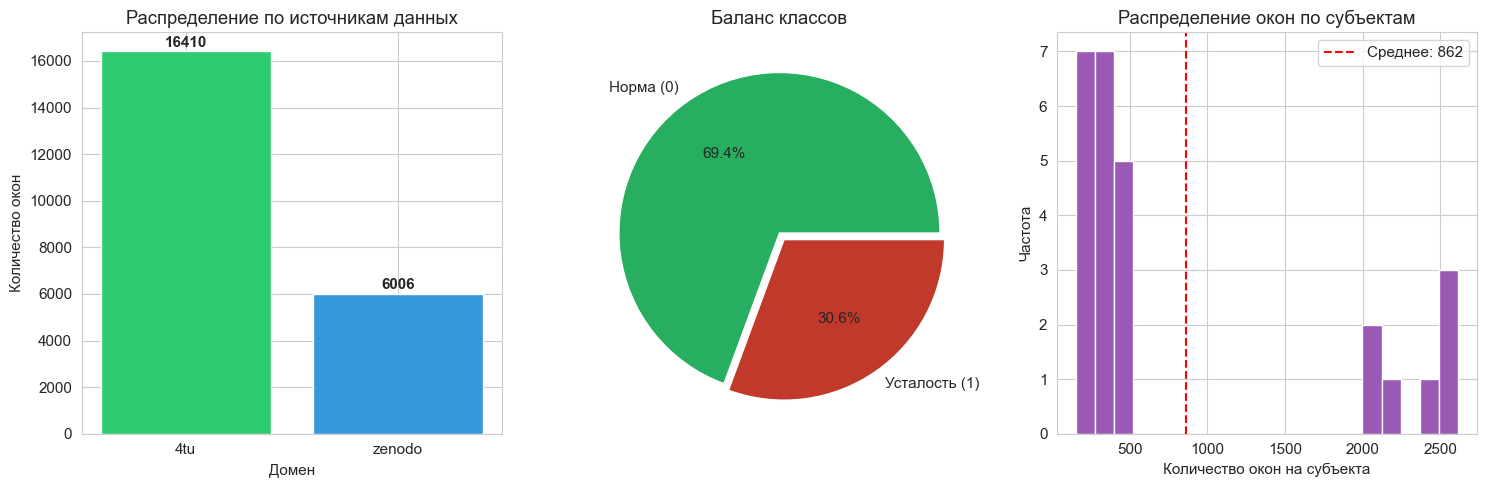

In [8]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
colors_domain = ['#2ecc71', '#3498db', '#e67e22'][:len(domain_counts)]
axes[0].bar(domain_counts.index, domain_counts.values, color=colors_domain)
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество окон')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors_class = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'],
            autopct='%1.1f%%', colors=colors_class, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение окон по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение окон по субъектам')
axes[2].set_xlabel('Количество окон на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


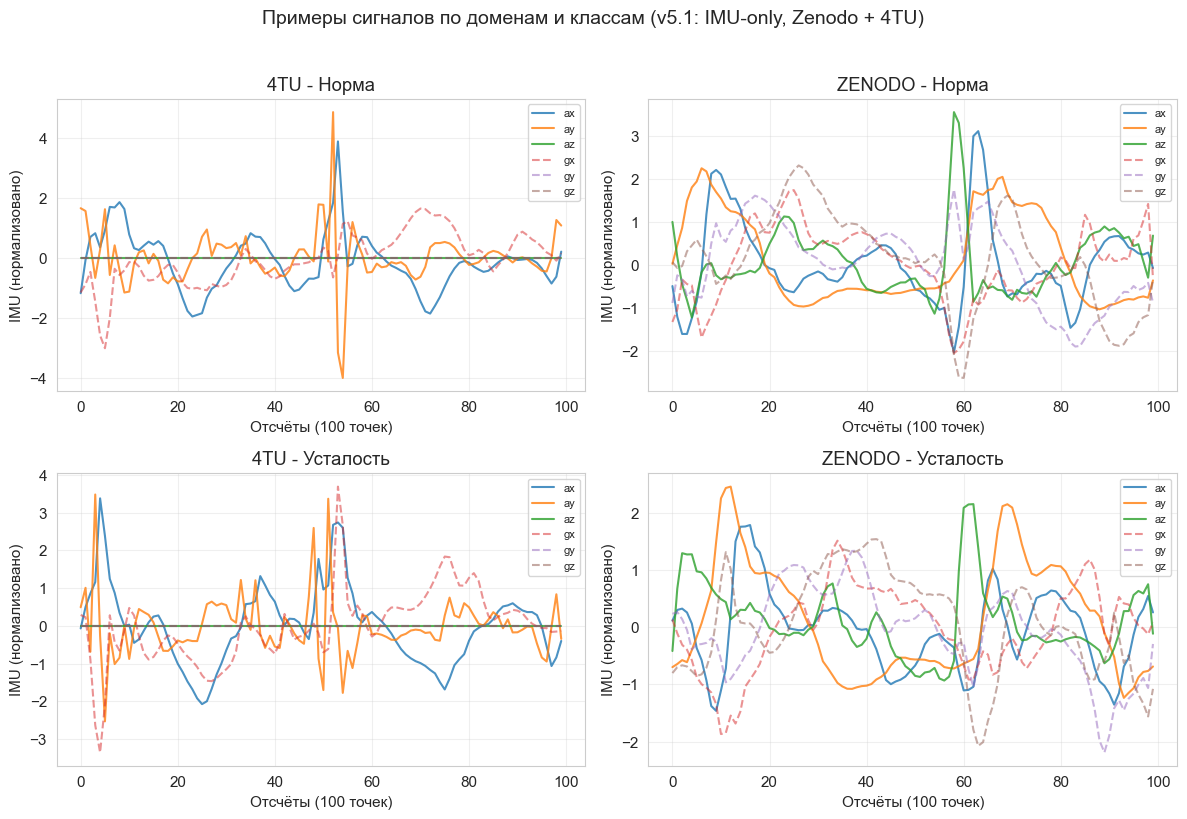

In [9]:
# Визуализация примеров сигналов по доменам (v5.1: IMU-only, Zenodo + 4TU)
unique_domains = sorted(np.unique(domains))
n_domains = len(unique_domains)
fig, axes = plt.subplots(2, n_domains, figsize=(6 * n_domains, 8))

for col, domain in enumerate(unique_domains):
    domain_mask = domains == domain

    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]

        ax = axes[row, col] if n_domains > 1 else axes[row]

        if len(indices) > 0:
            idx = indices[0]
            X = X_imu_all[idx]  # (100, 6)
            time_axis = np.arange(X.shape[0])

            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x","y","z"][ch]}', alpha=0.8)
            for ch in range(3, min(6, X.shape[1])):  # gx, gy, gz
                ax.plot(time_axis, X[:, ch], label=f'g{["x","y","z"][ch-3]}', alpha=0.5, linestyle='--')

            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек)')
            ax.set_ylabel('IMU (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры сигналов по доменам и классам (v5.1: IMU-only, Zenodo + 4TU)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Подготовка данных для обучения

Стратегия разбиения:
- **Subject-level split**: train/val/test разбиение по субъектам (не по окнам), стратифицировано по доменам
- **LOSO (Leave-One-Subject-Out)**: для оценки обобщающей способности
- Размеры: 60% train / 20% val / 20% test

In [10]:
# Конфигурация данных (v5.1: IMU-only, Zenodo + 4TU)
IMU_CHANNELS = 6      # ax, ay, az, gx, gy, gz
TARGET_SAMPLES = 100  # 100 точек на окно

print(f"✅ Данные подготовлены (v5.1 — IMU-only, без PhysioNet):")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {len(np.unique(domains))}")
print(f"   NaN (IMU):      {np.isnan(X_imu_all).sum()}")

✅ Данные подготовлены (v5.1 — IMU-only, без PhysioNet):
   X_imu shape:    (22416, 100, 6)
   y shape:        (22416,)
   Субъектов:      26
   Доменов:        2
   NaN (IMU):      0


In [11]:
# Create LOSO folds
def create_loso_folds(subjects):
    """Create Leave-One-Subject-Out folds."""
    unique_subjects = np.unique(subjects)
    folds = []

    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })

    return folds


def create_subject_split(subjects, domains, y=None, test_size=0.2, val_size=0.2, random_state=7321):
    """Subject-level split (not window-level), stratified by domain."""
    if test_size + val_size >= 1.0:
        raise ValueError("test_size + val_size must be < 1.0")

    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates(subset='sid')

    # Ensure each subject belongs to a single domain
    dom_counts = subj_df.groupby('sid')['domain'].nunique()
    if (dom_counts > 1).any():
        bad_subjects = dom_counts[dom_counts > 1].index.tolist()
        raise ValueError(f"Subjects mapped to multiple domains: {bad_subjects}")

    sid_values = subj_df['sid'].to_numpy()
    sid_domains = subj_df['domain'].to_numpy()

    strat_test = sid_domains if len(np.unique(sid_domains)) > 1 else None
    sid_train_val, sid_test = train_test_split(
        sid_values,
        test_size=test_size,
        random_state=random_state,
        stratify=strat_test,
    )

    val_rel = val_size / (1.0 - test_size)
    train_val_df = subj_df[subj_df['sid'].isin(sid_train_val)]
    train_val_domains = train_val_df.set_index('sid').loc[sid_train_val, 'domain'].to_numpy()
    strat_val = train_val_domains if len(np.unique(train_val_domains)) > 1 else None

    sid_train, sid_val = train_test_split(
        sid_train_val,
        test_size=val_rel,
        random_state=random_state,
        stratify=strat_val,
    )

    train_idx = np.where(np.isin(subjects, sid_train))[0]
    val_idx = np.where(np.isin(subjects, sid_val))[0]
    test_idx = np.where(np.isin(subjects, sid_test))[0]

    if y is not None:
        for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
            if len(np.unique(y[idx])) < 2:
                raise ValueError(f"Split {name} has one class only. Adjust split parameters.")

    split_info = {
        'train_subjects': sorted(sid_train.tolist()),
        'val_subjects': sorted(sid_val.tolist()),
        'test_subjects': sorted(sid_test.tolist()),
    }
    return train_idx, val_idx, test_idx, split_info


def print_split_summary(name, idx, subjects, domains, y, total_n):
    split_subjects = np.unique(subjects[idx])
    dom_values, dom_counts = np.unique(domains[idx], return_counts=True)
    class_counts = np.bincount(y[idx].astype(int), minlength=2)

    print(f"{name}: {len(idx)} windows ({len(idx)/total_n*100:.1f}%) | subjects: {len(split_subjects)}")
    print(f"  Domains: {dict(zip(dom_values.tolist(), dom_counts.tolist()))}")
    print(f"  Classes: 0 -> {class_counts[0]}, 1 -> {class_counts[1]}, pos_ratio={y[idx].mean():.1%}")


# Build split
train_idx, val_idx, test_idx, split_info = create_subject_split(
    subjects,
    domains,
    y=y_all,
    test_size=0.2,
    val_size=0.2,
    random_state=SEED,
)

print_split_summary('Train', train_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Val', val_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Test', test_idx, subjects, domains, y_all, len(y_all))

print("Subjects by split:")
print(f"  Train ({len(split_info['train_subjects'])}): {', '.join(split_info['train_subjects'])}")
print(f"  Val   ({len(split_info['val_subjects'])}): {', '.join(split_info['val_subjects'])}")
print(f"  Test  ({len(split_info['test_subjects'])}): {', '.join(split_info['test_subjects'])}")


Train: 13225 windows (59.0%) | subjects: 15
  Domains: {'4tu': 9762, 'zenodo': 3463}
  Classes: 0 -> 9157, 1 -> 4068, pos_ratio=30.8%
Val: 3379 windows (15.1%) | subjects: 5
  Domains: {'4tu': 2012, 'zenodo': 1367}
  Classes: 0 -> 2230, 1 -> 1149, pos_ratio=34.0%
Test: 5812 windows (25.9%) | subjects: 6
  Domains: {'4tu': 4636, 'zenodo': 1176}
  Classes: 0 -> 4165, 1 -> 1647, pos_ratio=28.3%
Subjects by split:
  Train (15): 4tu_2, 4tu_3, 4tu_4, 4tu_8, zenodo_10, zenodo_11, zenodo_13, zenodo_14, zenodo_15, zenodo_17, zenodo_18, zenodo_19, zenodo_5, zenodo_6, zenodo_9
  Val   (5): 4tu_1, zenodo_22, zenodo_23, zenodo_4, zenodo_8
  Test  (6): 4tu_5, 4tu_6, zenodo_12, zenodo_20, zenodo_21, zenodo_7


## 4. Архитектура модели (v5.1: IMU-only CNN + Temporal Attention)

### Структура сети FatigueCNN_Simple:

```
IMU Input (batch, 100, 6) — ax, ay, az, gx, gy, gz
        ↓
  Conv1D(6→64, k=7)→BN→ReLU→Pool(2)→Drop(0.2)
  Conv1D(64→64, k=5)→BN→ReLU→Pool(2)→Drop(0.2)
  Conv1D(64→64, k=3)→BN→ReLU
        ↓
  TemporalAttention (64 → 64-dim)
        ↓
  FC(64→32)→ReLU→Dropout(0.4)
  FC(32→1)→Sigmoid
```

**Параметров:** ~27K (было ~80K с Physio+Attention, ~474K с LSTM)

**Изменения v5.1 vs v5.0:**
- Удалён датасет PhysioNet (~47% окон, ACC-only → domain shift)
- Оставлены только Zenodo + 4TU (полный 6-канальный IMU)

In [31]:
# ── Аугментация данных (on-the-fly, v5.1: IMU-only) ──

from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample


def add_gaussian_noise(x, sigma=0.05):
    """x: (T, C) -> (T, C)"""
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)


def time_warp(x, sigma=0.2, knots=4):
    """Non-linear time warping via cubic spline."""
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([
        CubicSpline(t_orig, x[:, c])(t_warped) for c in range(C)
    ], axis=-1).astype(x.dtype)


def channel_dropout(x, p=0.15):
    """Randomly zero-out entire channels."""
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x


def magnitude_scale(x, s_min=0.8, s_max=1.2):
    """Scale amplitude by random factor per channel."""
    s = np.random.uniform(s_min, s_max, (1, x.shape[1])).astype(x.dtype)
    return x * s


def window_slice(x, crop_ratio=0.8):
    """Random crop + resample back to original length."""
    T, C = x.shape
    L = max(int(T * crop_ratio), 10)
    start = np.random.randint(0, T - L + 1)
    crop = x[start:start + L, :]
    return sp_resample(crop, T, axis=0).astype(x.dtype)


def time_reverse(x_imu):
    """Reverse time axis (IMU only)."""
    return x_imu[::-1, :].copy()


def imu_rotate(x_imu, max_deg=15.0):
    """Apply random small SO(3) rotation to acc and gyro axes."""
    def rand_rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K

    x = x_imu.copy()
    x[:, :3] = x[:, :3] @ rand_rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ rand_rot().T
    return x.astype(x_imu.dtype)


def augment_imu(x_imu):
    """Apply augmentation pipeline to a single IMU sample (v5.1: no physio)."""
    if np.random.rand() < 0.5:
        x_imu = add_gaussian_noise(x_imu, sigma=0.05)
    if np.random.rand() < 0.4:
        x_imu = time_warp(x_imu, sigma=0.2, knots=4)
    if np.random.rand() < 0.5:
        x_imu = magnitude_scale(x_imu, 0.8, 1.2)
    if np.random.rand() < 0.3:
        x_imu = window_slice(x_imu, crop_ratio=0.8)
    if np.random.rand() < 0.25:
        x_imu = time_reverse(x_imu)
    if np.random.rand() < 0.4:
        x_imu = imu_rotate(x_imu, max_deg=15.0)
    x_imu = channel_dropout(x_imu, p=0.15)
    return x_imu


# ── PyTorch Dataset (v5.1: IMU-only) ──

class FatigueDataset(Dataset):
    """Dataset for IMU-only fatigue data with optional augmentation."""

    def __init__(self, X_imu, y, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.y = y.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_imu = self.X_imu[idx].copy()
        y = self.y[idx]

        if self.augment:
            x_imu = augment_imu(x_imu)

        return torch.FloatTensor(x_imu), torch.tensor(y, dtype=torch.float32)


# ── Temporal Attention ──

class TemporalAttention(nn.Module):
    """
    Lightweight single-head temporal attention over CNN feature maps.
    Input:  (B, C, T)  Output: (B, C)
    """
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * weights).sum(dim=-1)  # (B, C)


# ── IMU Encoder with Attention ──

class IMUEncoderWithAttention(nn.Module):
    """CNN encoder for IMU with Temporal Attention instead of GAP."""
    def __init__(self, in_channels=6, out_channels=64, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return self.attention(x)


# ── FatigueCNN_Simple: IMU-only CNN + Temporal Attention (v5.1) ──

class FatigueCNN_Simple(nn.Module):
    """
    IMU-only CNN + Temporal Attention for fatigue detection.
    v5.1: removed Physio branch + LSTM + PhysioNet dataset to reduce overfitting.
    """
    def __init__(self, imu_channels=6, dropout=0.525, encoder_dropout=0.35, output_dim=16):
        super().__init__()
        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=imu_channels, out_channels=output_dim, dropout=encoder_dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(output_dim, output_dim // 2), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(output_dim // 2, 1),
        )

    def forward(self, x_imu):
        imu_feat = self.imu_encoder(x_imu)
        return self.classifier(imu_feat).squeeze(-1)

    def predict_proba(self, x_imu):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu))


# ── Create model and show params ──

model_simple = FatigueCNN_Simple(imu_channels=IMU_CHANNELS).to(DEVICE)

params_simple = sum(p.numel() for p in model_simple.parameters())

print("=" * 65)
print("  MODEL INFO (v5.1: FatigueCNN_Simple, IMU-only, Zenodo + 4TU)")
print("=" * 65)
print(f"  FatigueCNN_Simple:  {params_simple:>10,} params")
print()

for name, mod in [('IMU Encoder (Attention)', model_simple.imu_encoder),
                  ('Classifier', model_simple.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:35s}: {p:>8,}")
print()

_x = torch.randn(4, 100, 6).to(DEVICE)
print(f"  Output shape: {model_simple(_x).shape}")
print()
print("Will train FatigueCNN_Simple (IMU-only, v5.1: без PhysioNet)")

  MODEL INFO (v5.1: FatigueCNN_Simple, IMU-only, Zenodo + 4TU)
  FatigueCNN_Simple:       3,082 params

  IMU Encoder (Attention)            :    2,937
  Classifier                         :      145

  Output shape: torch.Size([4])

Will train FatigueCNN_Simple (IMU-only, v5.1: без PhysioNet)


## 5. Обучение модели (v5.1: FatigueCNN_Simple, IMU-only, Zenodo + 4TU)

**Конфигурация:**
- `batch_size=32`, `epochs=50`, `lr=0.001`, `weight_decay=3e-4`
- `patience=4`, `min_delta=6e-3`, `label_smoothing=0.05`
- Optimizer: AdamW, Scheduler: CosineAnnealingLR
- EarlyStopping по val F1-macro
- WeightedRandomSampler (домены сбалансированы)

In [ ]:
# Training configuration (v5.1: IMU-only, anti-overfitting)
CONFIG = {
    'batch_size': 32,
    'epochs': 50,
    'lr': 1e-4,
    'weight_decay': 5e-03,
    'patience': 4,
    'min_delta': 2e-05,
    'label_smoothing': 0.015,
    'dropout': 0.525,
    'encoder_dropout': 0.375,
    'output_dim': 32,
}
# BEST:
# Best epoch: 31, Val F1: 0.7287
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 4, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}
# Best epoch: 2, Val F1: 0.6873
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}
# epoch: 30, Val F1: 0.7281
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.001, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}
# Best epoch: 28, Val F1: 0.6884
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.4, 'encoder_dropout': 0.3, 'output_dim': 16}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}
# epoch: 2, Val F1: 0.7204
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.0005, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}

# ALSO GOOD:
# Best epoch: 16, Val F1: 0.7284
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}
# Best epoch: 17, Val F1: 0.7260 , в конце падает, возможно переобучение
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.003, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.525, 'encoder_dropout': 0.35, 'output_dim': 32}
# {'batch_size': 32, 'epochs': 50, 'lr': 0.0005, 'weight_decay': 0.0001, 'patience': 6, 'min_delta': 0.0001, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 8}

# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 2e-05, 'patience': 5, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# 11 epochs, F1: 0.7086
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 4, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# 20 epochs, F1: 0.71
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.005, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}

# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 8, 'min_delta': 2e-05, 'label_smoothing': 0.01, 'dropout': 0.55, 'encoder_dropout': 0.4, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.001, 'patience': 8, 'min_delta': 2e-05, 'label_smoothing': 0.01, 'dropout': 0.55, 'encoder_dropout': 0.4, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.003, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.3, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.45, 'encoder_dropout': 0.3, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.4, 'encoder_dropout': 0.5, 'output_dim': 32}

# FAILED: 
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.001, 'patience': 8, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# Best epoch: 1, Val F1: 0.2538
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.0005, 'patience': 8, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.001, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.3, 'encoder_dropout': 0.2, 'output_dim': 32}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.005, 'patience': 8, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.005, 'patience': 4, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 16, 'min_delta': 2e-05, 'label_smoothing': 0.035, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.035, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# {'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.5, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.003, 'patience': 8, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.55, 'encoder_dropout': 0.4, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.003, 'patience': 8, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.6, 'encoder_dropout': 0.4, 'output_dim': 32}
# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.003, 'patience': 12, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.3, 'output_dim': 32}

# {'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.4, 'encoder_dropout': 0.3, 'output_dim': 32}

def compute_class_weights(y):
    """Compute positive class weight for BCEWithLogitsLoss."""
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 1.0
    return n_neg / n_pos


def compute_domain_weights(domains_arr):
    """Compute per-sample weight so each domain contributes equally."""
    unique_doms = np.unique(domains_arr)
    n_total = len(domains_arr)
    n_domains = len(unique_doms)
    dom_counts = {d: (domains_arr == d).sum() for d in unique_doms}
    weights = np.zeros(n_total, dtype=np.float64)
    for d in unique_doms:
        mask = domains_arr == d
        weights[mask] = n_total / (n_domains * dom_counts[d])
    return weights


class EarlyStopping:
    """Early stopping by metric where higher is better (e.g., F1)."""

    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None

    def __call__(self, score, model):
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def format_metric(value):
    return f"{value:.4f}" if np.isfinite(value) else "nan"


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """Compute binary metrics with edge-case handling."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }

    if np.unique(y_true).size < 2:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan
    else:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(recall_vals, precision_vals)

    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    """Select threshold by best F1-macro on validation."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    best_threshold, best_f1 = 0.5, -np.inf
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)
    return best_threshold, best_f1


class LabelSmoothingBCELoss(nn.Module):
    """BCEWithLogitsLoss with label smoothing and optional pos_weight."""
    def __init__(self, smoothing=0.05, pos_weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight, reduction='none'
        )
        return loss.mean()


def train_epoch(model, loader, optimizer, criterion, device):
    """Train one epoch (v5.1: IMU-only, 2-tuple batch)."""
    model.train()
    total_loss = 0.0

    for X_imu, y_batch in loader:
        X_imu = X_imu.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_imu)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    """Validate model (v5.1: IMU-only, 2-tuple batch)."""
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_imu, y_batch in loader:
            X_imu = X_imu.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_imu)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.array(all_probs, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)
    metrics, _ = compute_binary_metrics(all_labels, all_probs, threshold=threshold)

    if return_raw:
        return avg_loss, metrics, all_labels, all_probs
    return avg_loss, metrics


print("Training utilities ready (v5.1: IMU-only, Zenodo + 4TU)")
print(f"  CONFIG: lr={CONFIG['lr']}, wd={CONFIG['weight_decay']}, patience={CONFIG['patience']}, label_smoothing={CONFIG['label_smoothing']}")

Training utilities ready (v5.1: IMU-only, Zenodo + 4TU)
  CONFIG: lr=0.0001, wd=0.005, patience=4, label_smoothing=0.015


In [22]:
from torch.utils.data import WeightedRandomSampler

# Prepare data for training (v5.1: IMU-only + domain weighting, Zenodo + 4TU)
train_dataset = FatigueDataset(
    X_imu_all[train_idx], y_all[train_idx],
    augment=True,
)
val_dataset = FatigueDataset(
    X_imu_all[val_idx], y_all[val_idx],
    augment=False,
)
test_dataset = FatigueDataset(
    X_imu_all[test_idx], y_all[test_idx],
    augment=False,
)

# v5.1: Domain-weighted sampler — each domain contributes equally per batch
train_domain_weights = compute_domain_weights(domains[train_idx])
train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(train_domain_weights).double(),
    num_samples=len(train_idx),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} samples (augmented + domain-weighted), {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

# Domain weight distribution
for d in np.unique(domains[train_idx]):
    d_mask = domains[train_idx] == d
    w = train_domain_weights[d_mask][0]
    print(f"  {d}: {d_mask.sum()} windows, weight={w:.3f}")

# ── Use FatigueCNN_Simple (v5.1: IMU-only, Zenodo + 4TU) ──
model = FatigueCNN_Simple(
    imu_channels=IMU_CHANNELS,
    dropout=CONFIG['dropout'],
    encoder_dropout=CONFIG['encoder_dropout'],
    output_dim=CONFIG['output_dim'],
).to(DEVICE)

# Class weights + label smoothing
pos_weight = compute_class_weights(y_all[train_idx])
criterion = LabelSmoothingBCELoss(
    smoothing=CONFIG['label_smoothing'],
    pos_weight=torch.tensor([pos_weight]).to(DEVICE),
)
print(f"\nModel: FatigueCNN_Simple (IMU-only + Temporal Attention, v5.1)")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Positive class weight: {pos_weight:.2f}")
print(f"Label smoothing: {CONFIG['label_smoothing']}")
print(f"Domain-weighted sampling: enabled (2 domains: zenodo, 4tu)")
print(f"Augmentation: enabled (7 IMU techniques)")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early stopping by F1
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

Train: 13225 samples (augmented + domain-weighted), 414 batches
Val:   3379 samples, 106 batches
Test:  5812 samples, 182 batches
  4tu: 9762 windows, weight=0.677
  zenodo: 3463 windows, weight=1.909

Model: FatigueCNN_Simple (IMU-only + Temporal Attention, v5.1)
Parameters: 10,642
Positive class weight: 2.25
Label smoothing: 0.015
Domain-weighted sampling: enabled (2 domains: zenodo, 4tu)
Augmentation: enabled (7 IMU techniques)


In [23]:
# Train CNN model (v5.1: FatigueCNN_Simple, IMU-only, без PhysioNet)
print("=" * 60)
print("TRAINING FatigueCNN_Simple (v5.1: без PhysioNet)")
print("=" * 60)
print(CONFIG)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'lr': [],
}

best_val_f1 = -np.inf
best_epoch = 0
best_threshold = 0.5
best_threshold_f1 = -np.inf

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_metrics, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, threshold=0.5, return_raw=True,
    )

    val_f1 = val_metrics['f1_macro']
    val_auc = val_metrics['roc_auc']
    val_pr_auc = val_metrics['pr_auc']
    val_bal_acc = val_metrics['balanced_acc']

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    if val_f1 > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_threshold, best_threshold_f1 = find_best_threshold(val_labels, val_probs)
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model_v5.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val AUC: {format_metric(val_auc)} | "
            f"LR: {current_lr:.6f}"
        )

    if early_stopping(val_f1, model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

# Restore best
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\nTraining completed")
print(f"Best epoch: {best_epoch}, Val F1: {best_val_f1:.4f}")
print(f"Best threshold: {best_threshold:.3f} (F1={best_threshold_f1:.4f})")

TRAINING FatigueCNN_Simple (v5.1: без PhysioNet)
{'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 4, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}
Epoch   1/50 | Train Loss: 0.9869 | Val Loss: 0.8971 | Val F1: 0.6387 | Val AUC: 0.7538 | LR: 0.000100
Epoch   5/50 | Train Loss: 0.8506 | Val Loss: 0.8426 | Val F1: 0.6708 | Val AUC: 0.8029 | LR: 0.000098
Epoch  10/50 | Train Loss: 0.8242 | Val Loss: 0.8328 | Val F1: 0.6835 | Val AUC: 0.8086 | LR: 0.000091
Epoch  15/50 | Train Loss: 0.8006 | Val Loss: 0.8194 | Val F1: 0.6889 | Val AUC: 0.8147 | LR: 0.000080
Epoch  20/50 | Train Loss: 0.8026 | Val Loss: 0.8129 | Val F1: 0.7023 | Val AUC: 0.8207 | LR: 0.000066
Epoch  25/50 | Train Loss: 0.7982 | Val Loss: 0.8103 | Val F1: 0.7100 | Val AUC: 0.8201 | LR: 0.000050
Epoch  30/50 | Train Loss: 0.7766 | Val Loss: 0.8175 | Val F1: 0.7274 | Val AUC: 0.8229 | LR: 0.000035
Epoch  35/50 | Train Loss: 0.7789 | V

{'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 4, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}


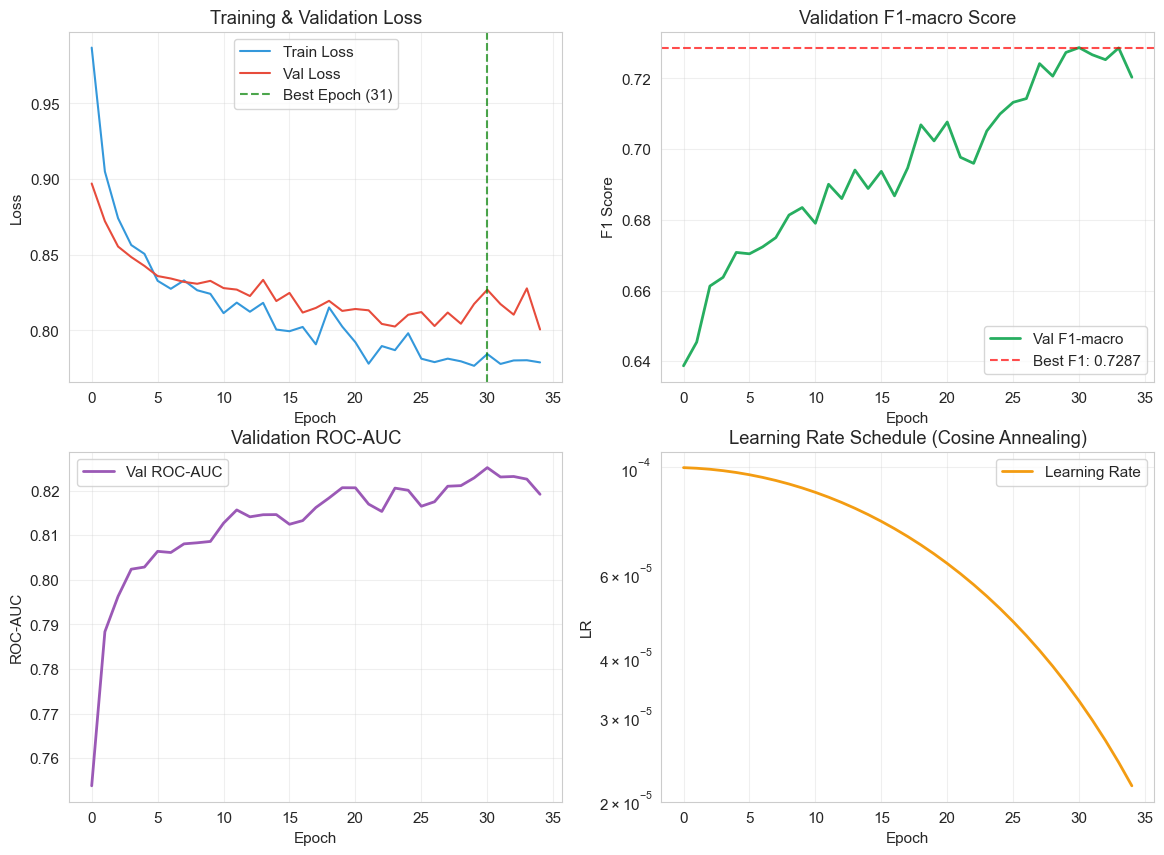

In [24]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.005, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.015, 'dropout': 0.525, 'encoder_dropout': 0.375, 'output_dim': 32}


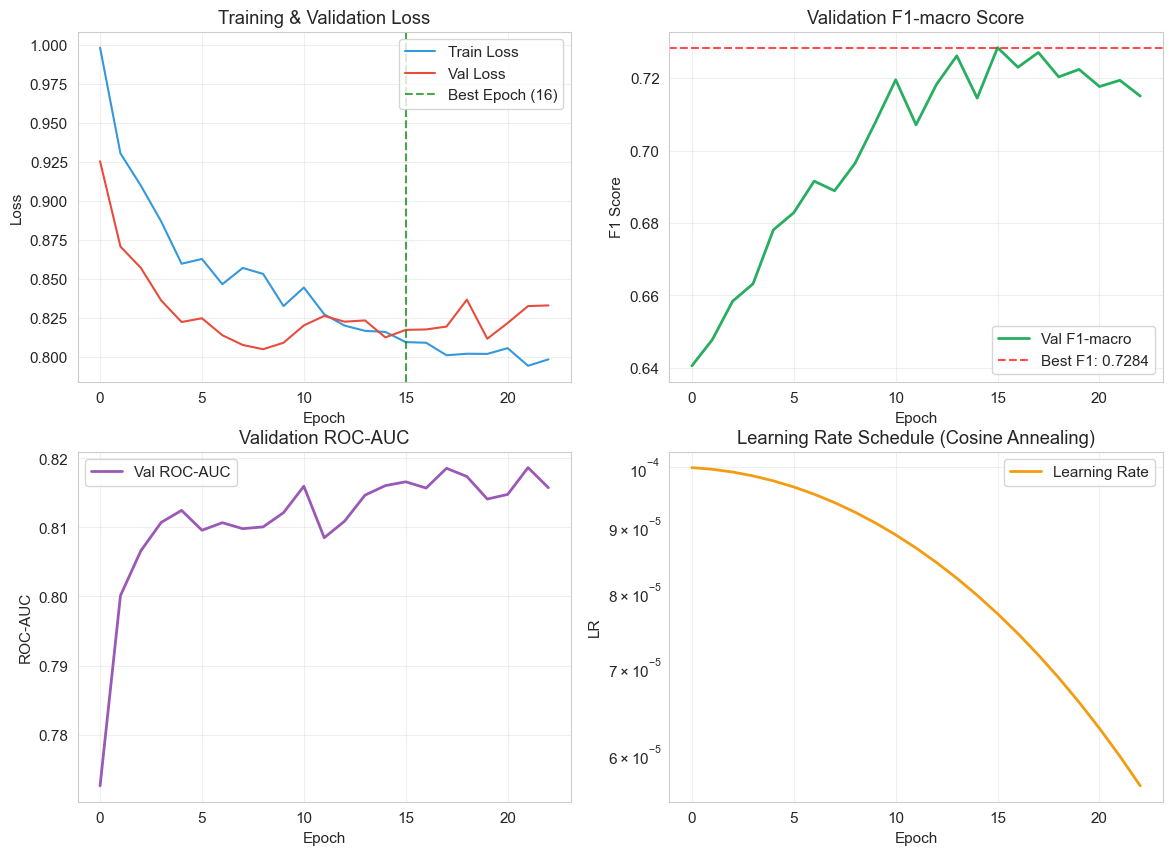

In [20]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 32, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.003, 'patience': 7, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.525, 'encoder_dropout': 0.35, 'output_dim': 32}


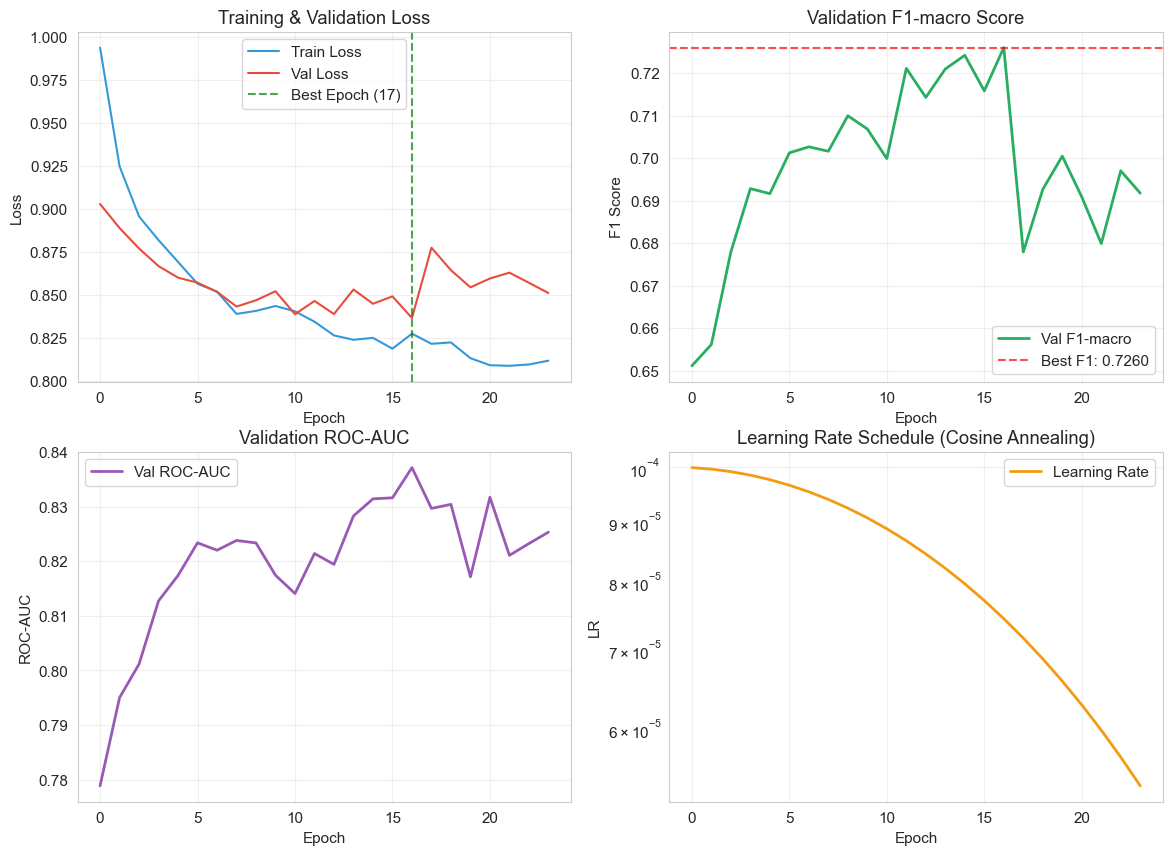

In [16]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}


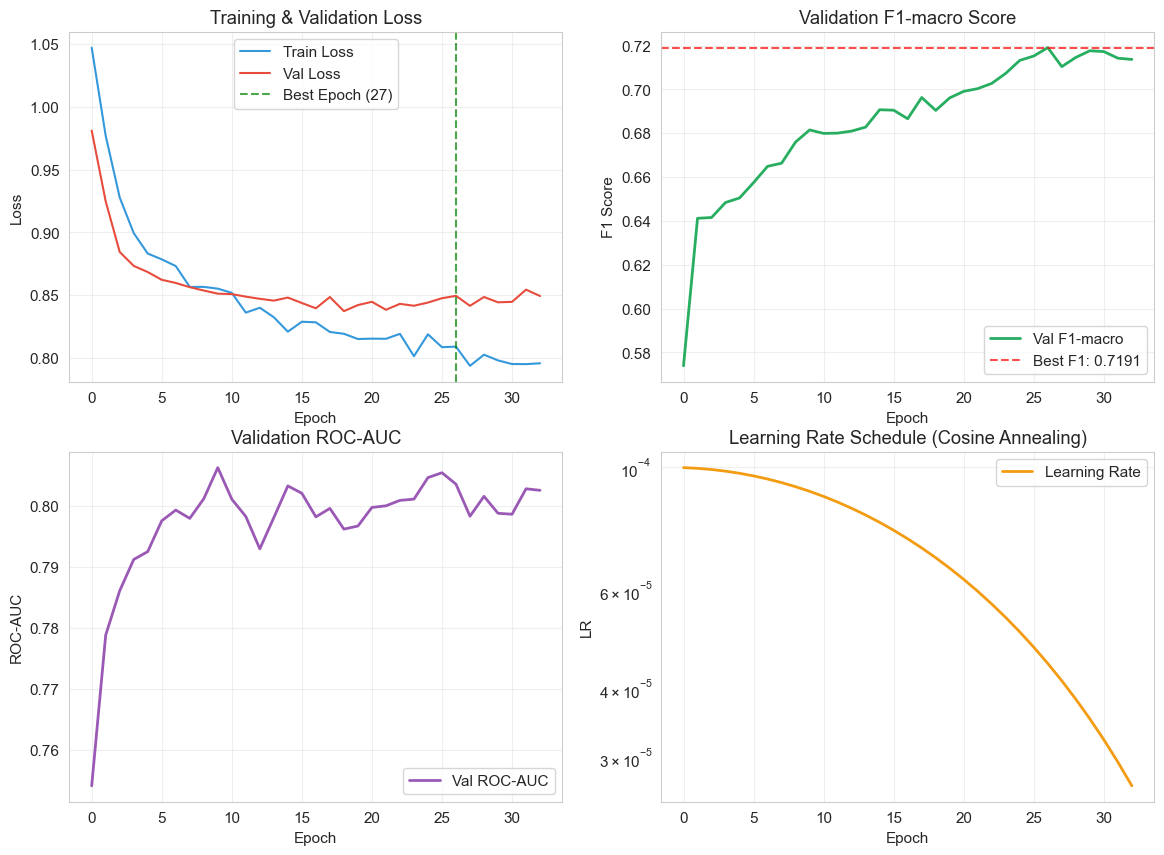

In [101]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.001, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.15, 'dropout': 0.35, 'encoder_dropout': 0.25, 'output_dim': 16}


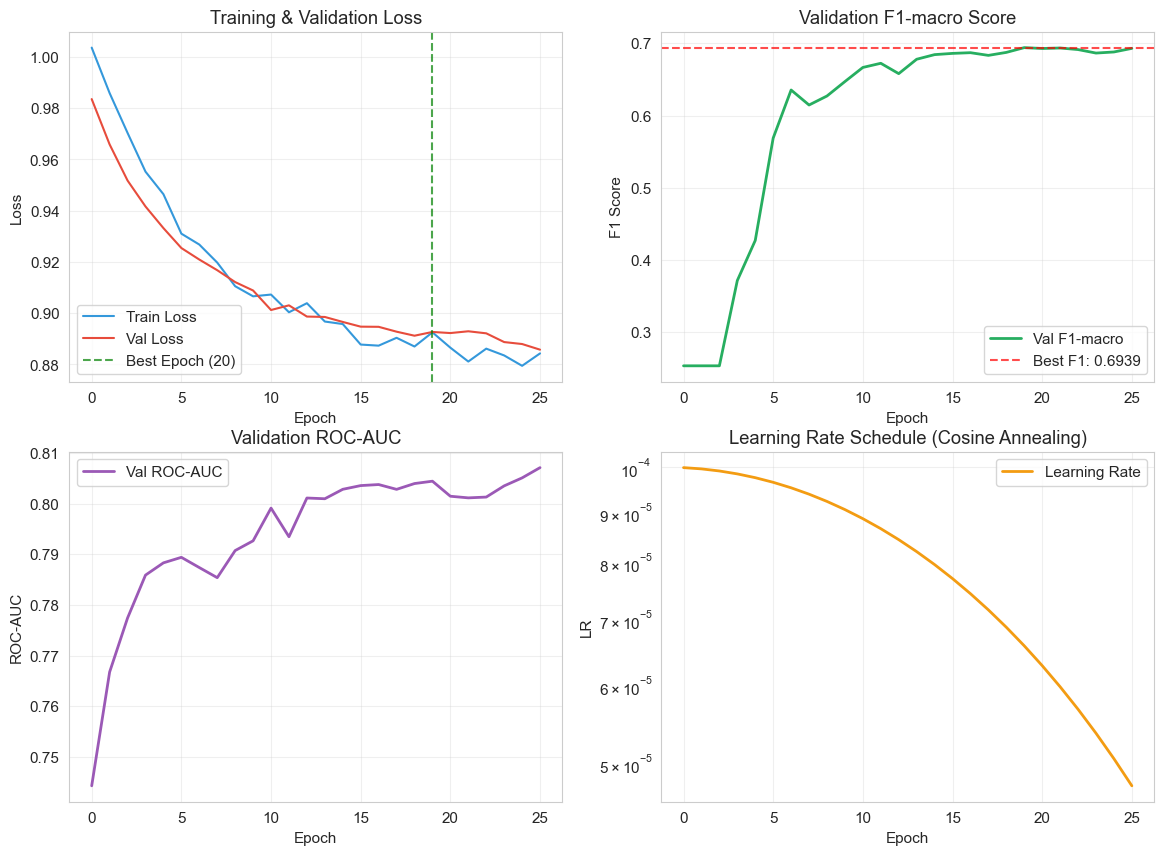

In [83]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.001, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.35, 'encoder_dropout': 0.25, 'output_dim': 16}


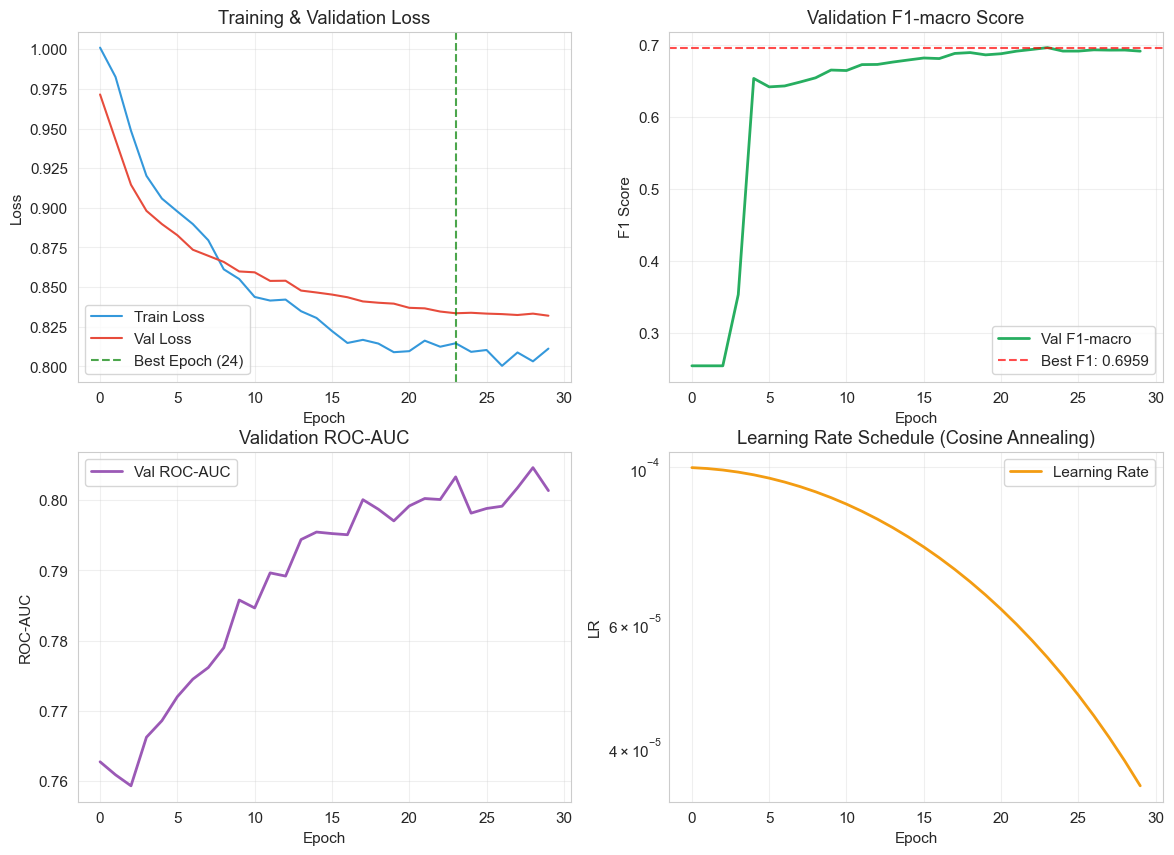

In [79]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.4, 'encoder_dropout': 0.3, 'output_dim': 16}


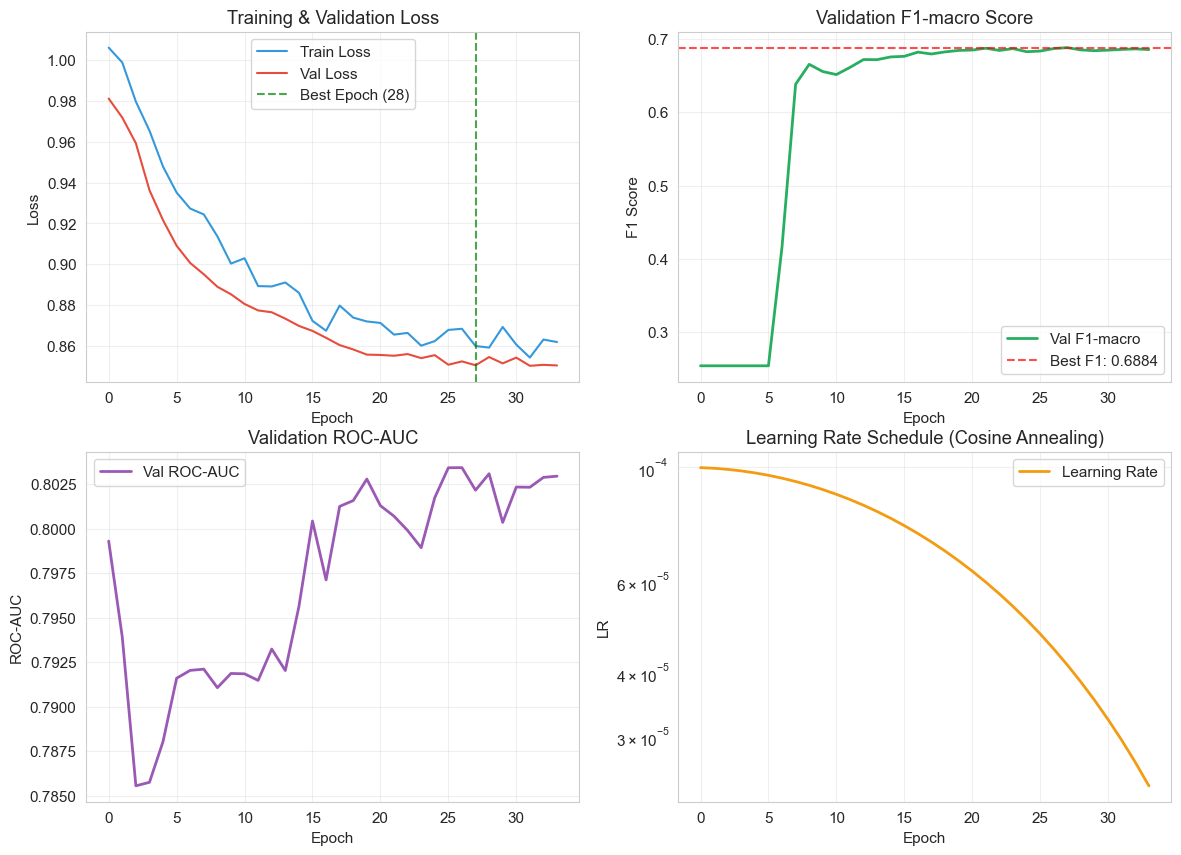

In [75]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}


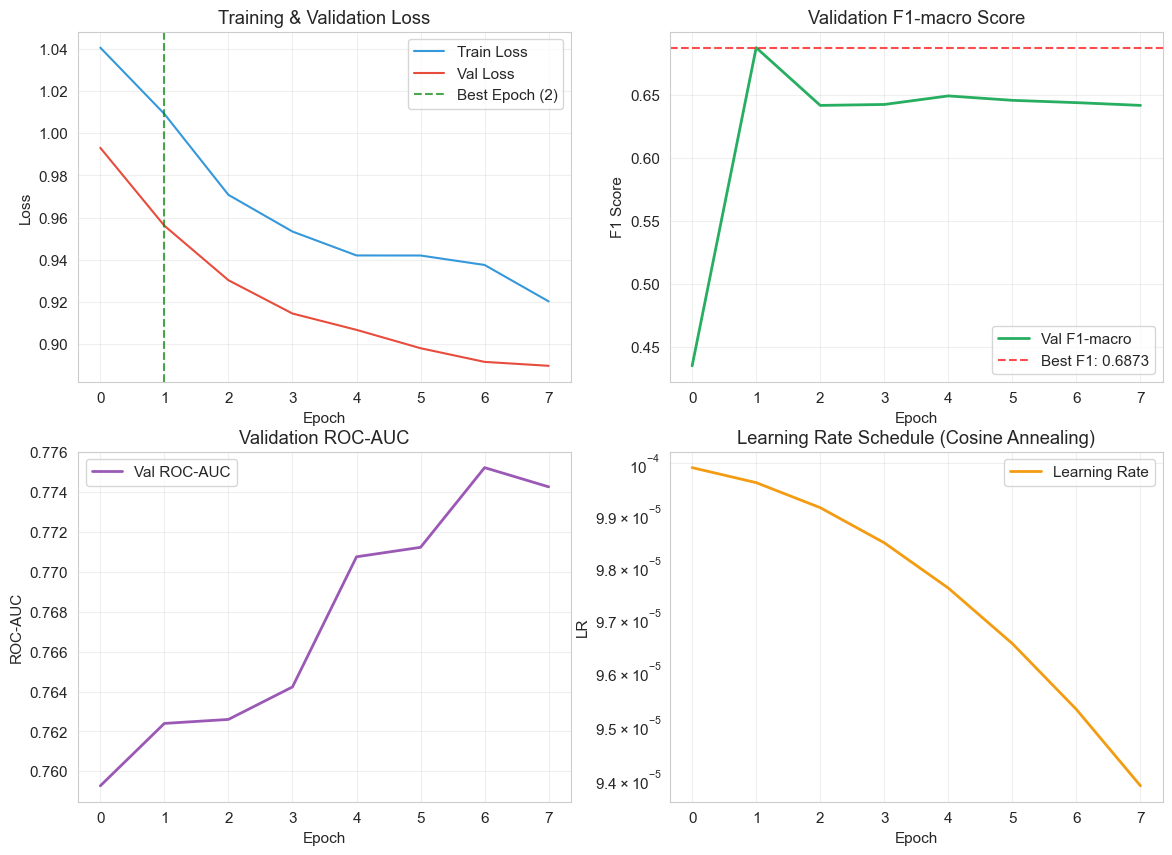

In [71]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.001, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}


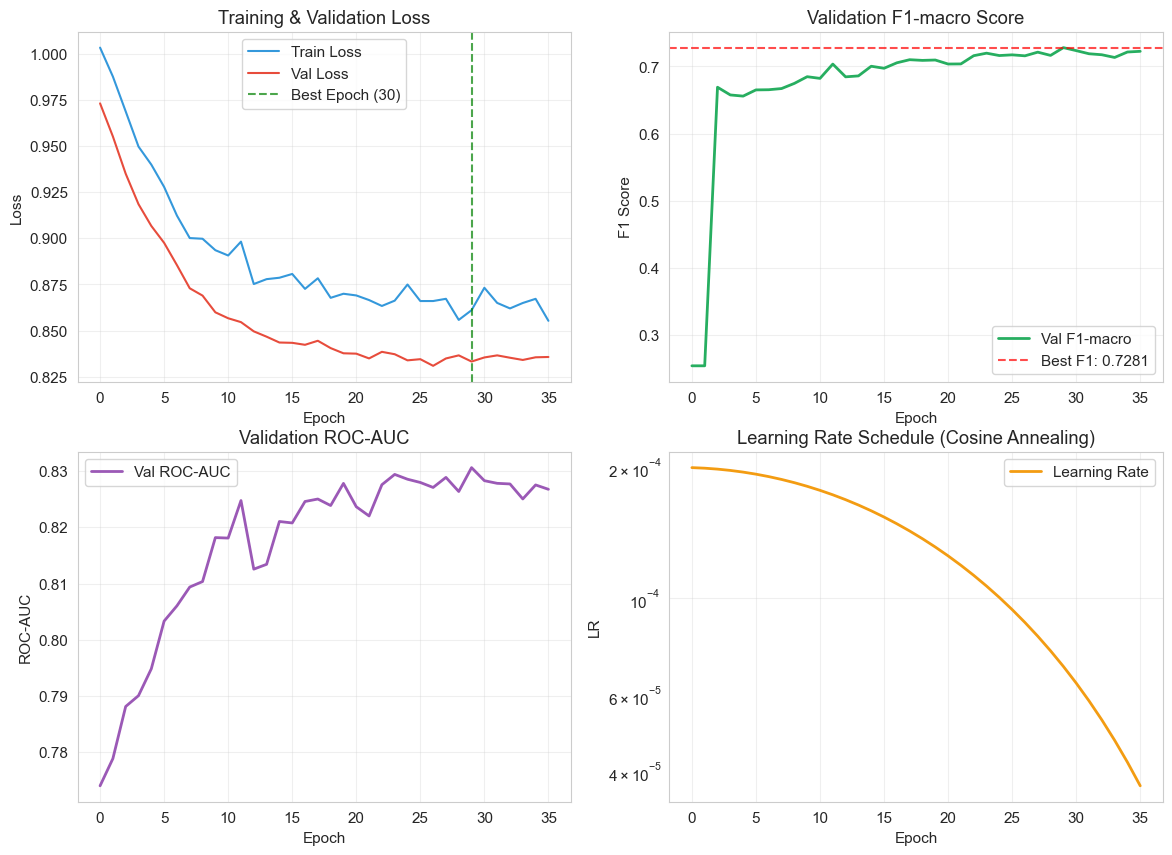

In [52]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.002, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.4, 'encoder_dropout': 0.5, 'output_dim': 32}


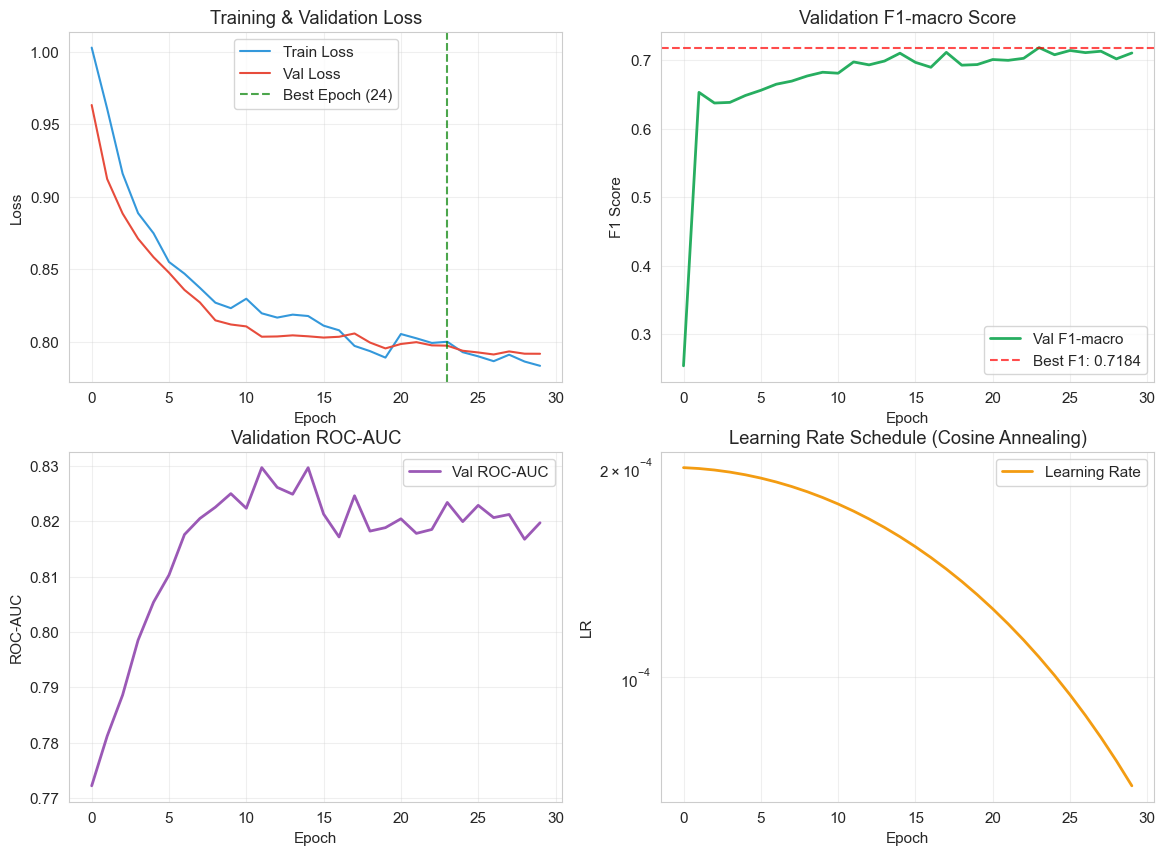

In [24]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.003, 'patience': 6, 'min_delta': 0.0002, 'label_smoothing': 0.01, 'dropout': 0.5, 'encoder_dropout': 0.3, 'output_dim': 32}


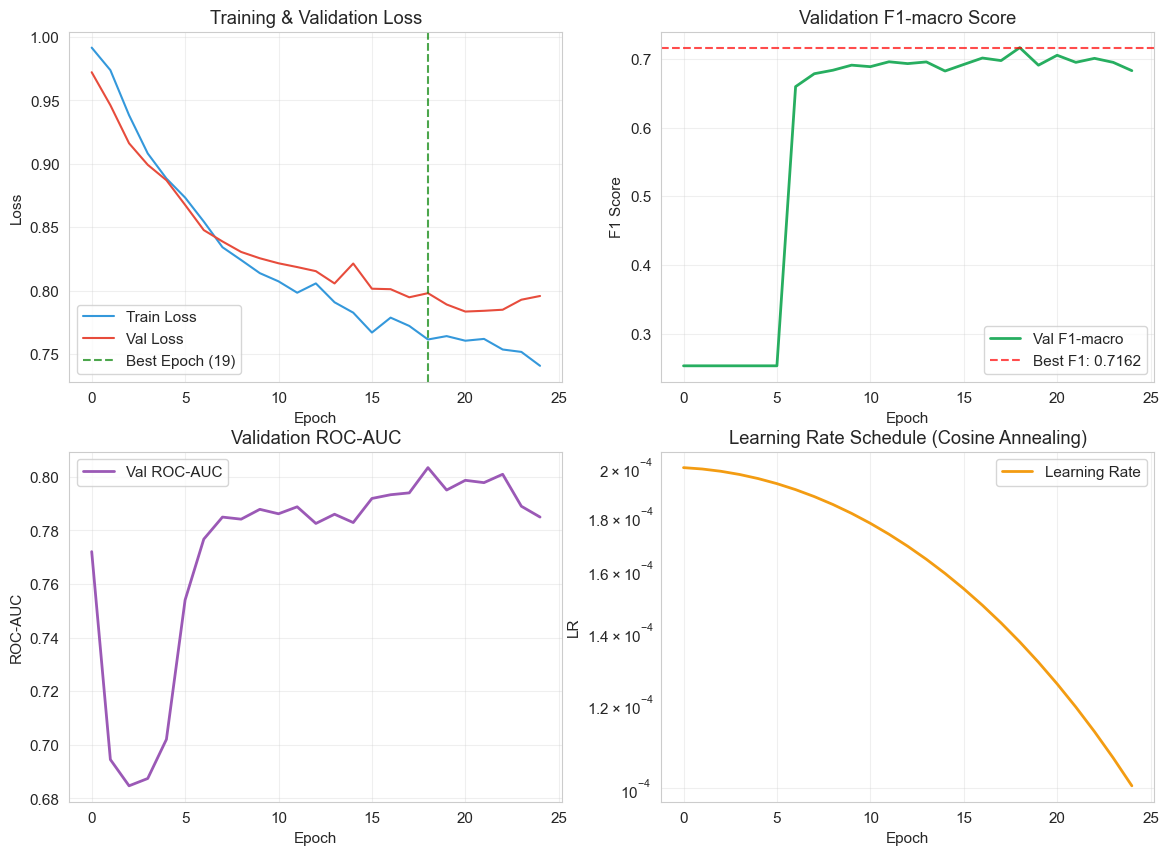

In [177]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 0.001, 'patience': 8, 'min_delta': 2e-05, 'label_smoothing': 0.01, 'dropout': 0.55, 'encoder_dropout': 0.4, 'output_dim': 32}


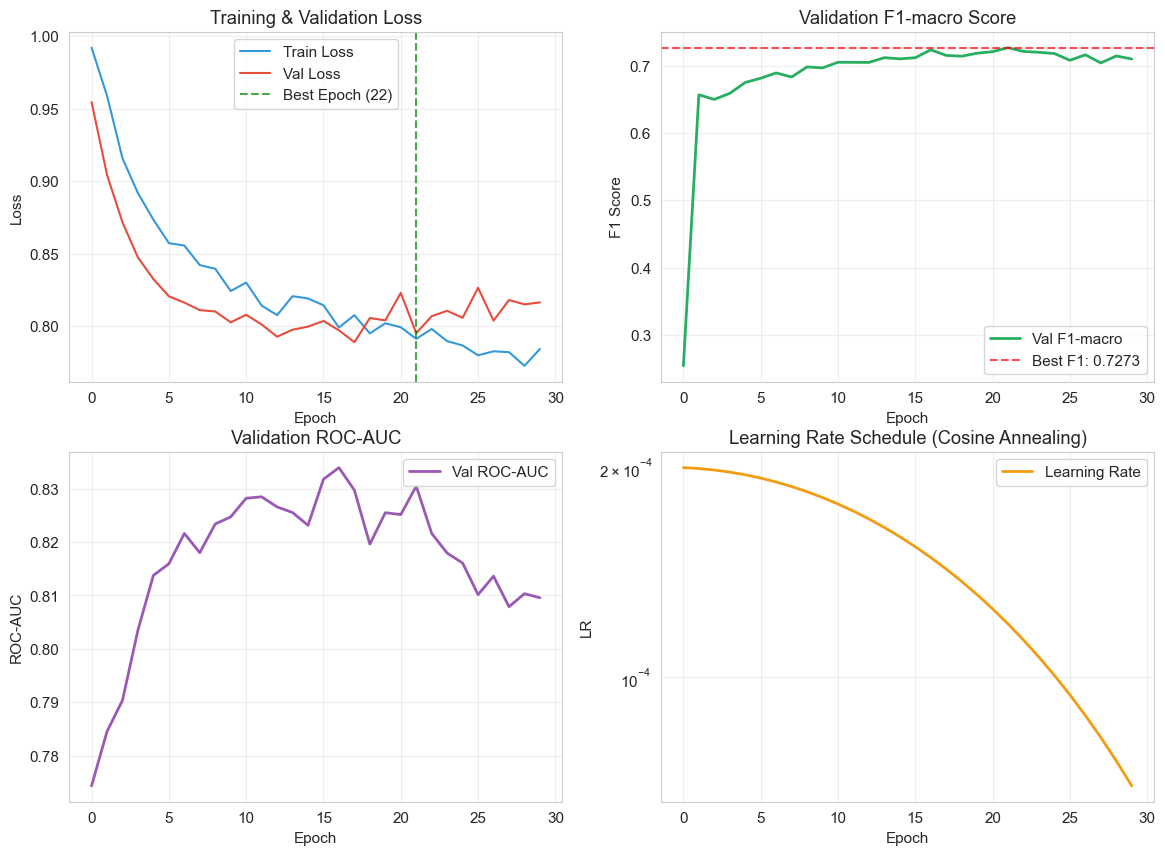

In [157]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 256, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 8, 'min_delta': 2e-05, 'label_smoothing': 0.01, 'dropout': 0.55, 'encoder_dropout': 0.4, 'output_dim': 32}


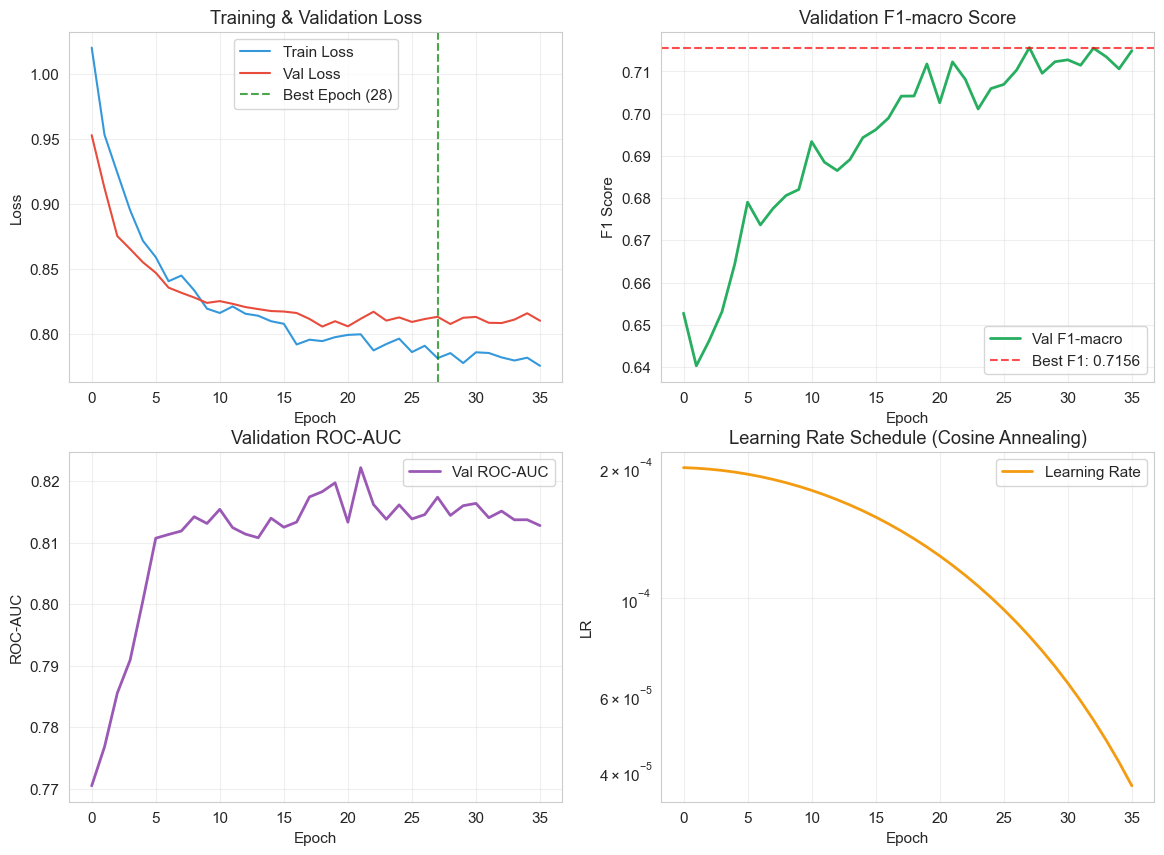

In [153]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 2e-05, 'label_smoothing': 0.025, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 24}


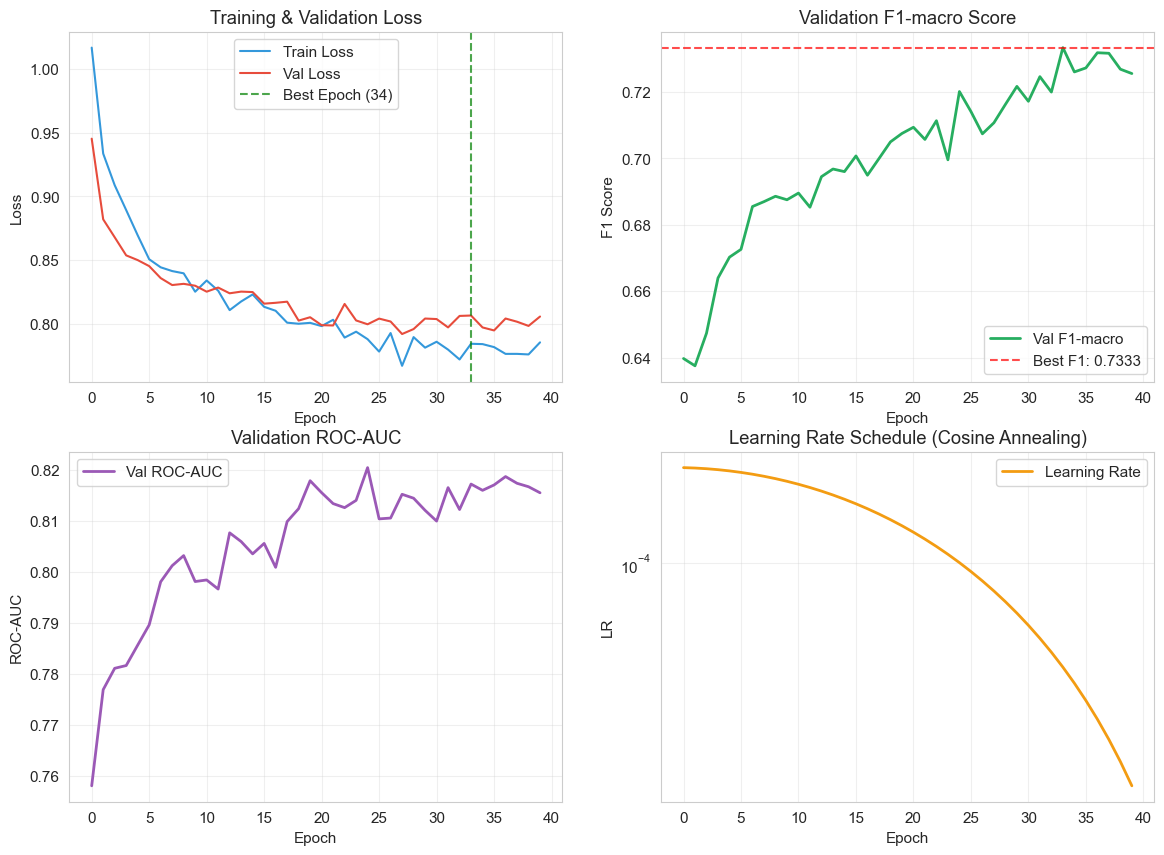

In [137]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 2e-05, 'label_smoothing': 0.025, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}


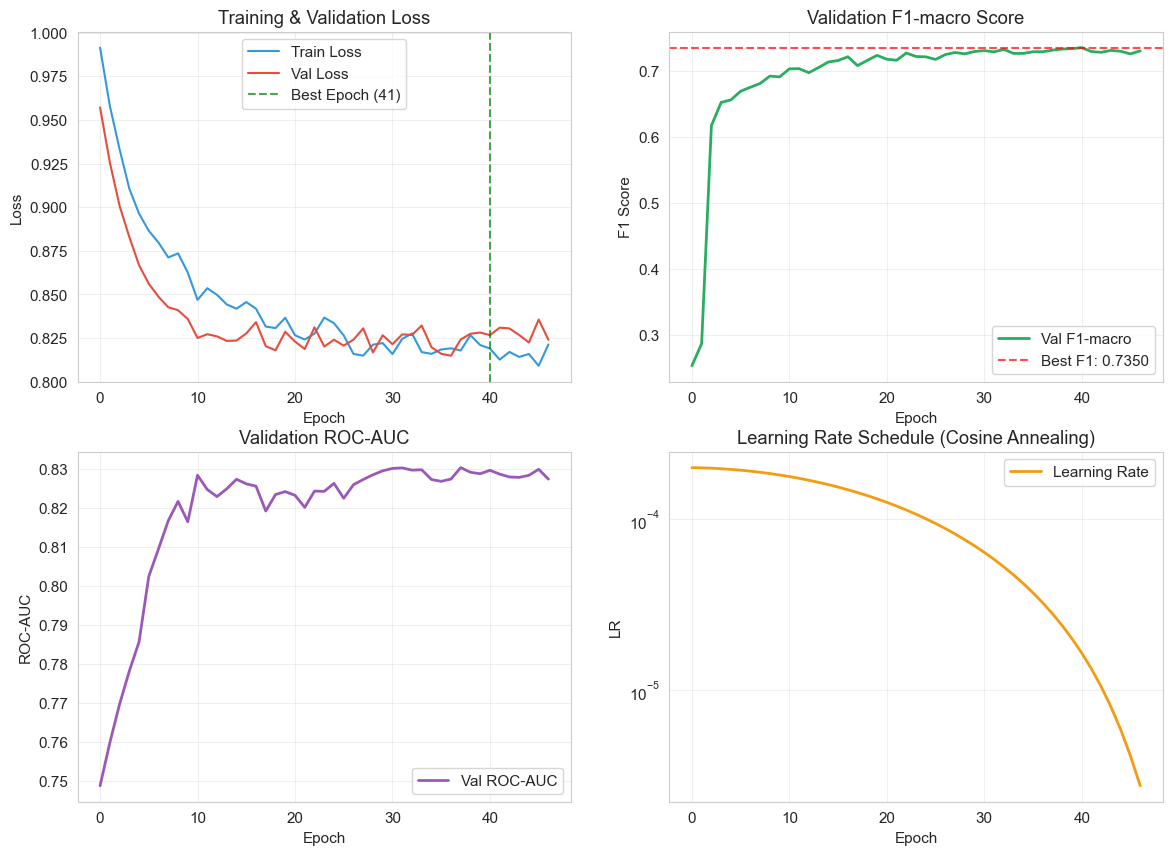

In [133]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 3e-05, 'patience': 6, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 16}


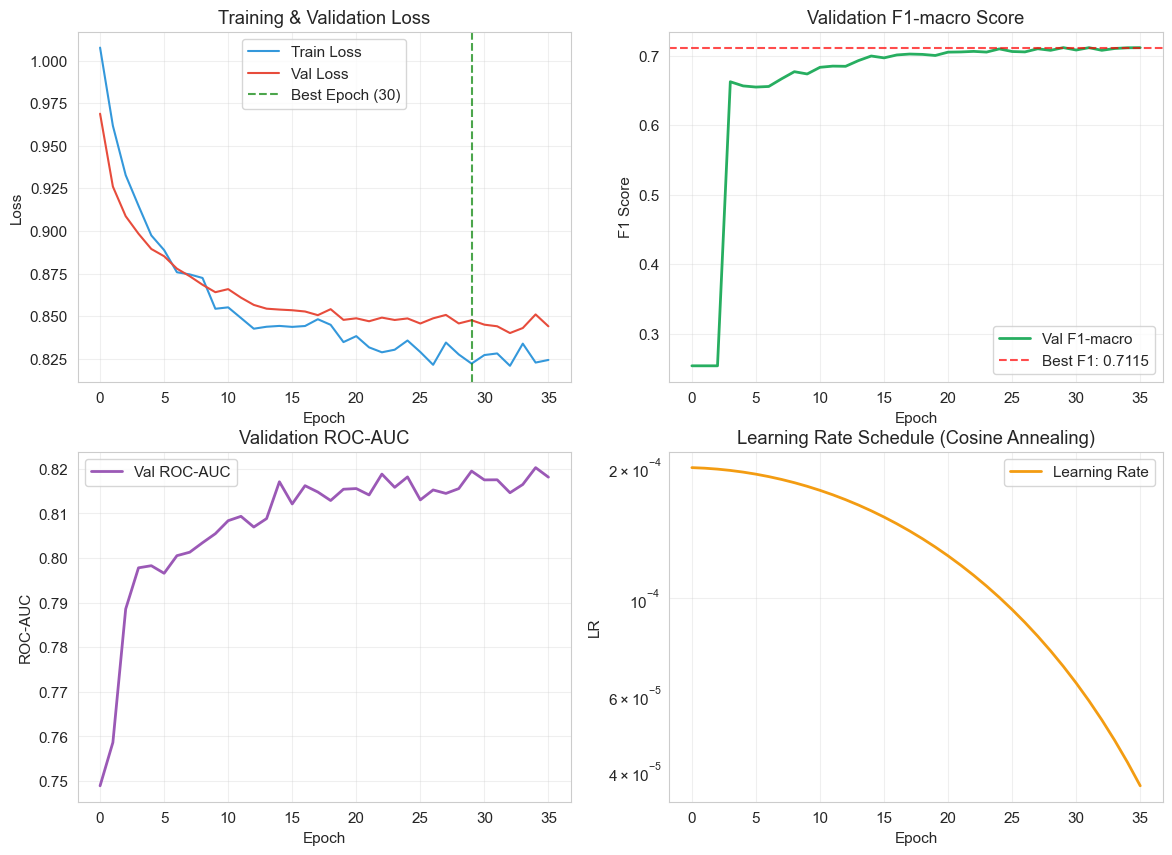

In [129]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0002, 'weight_decay': 2e-05, 'patience': 5, 'min_delta': 2e-05, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 32}


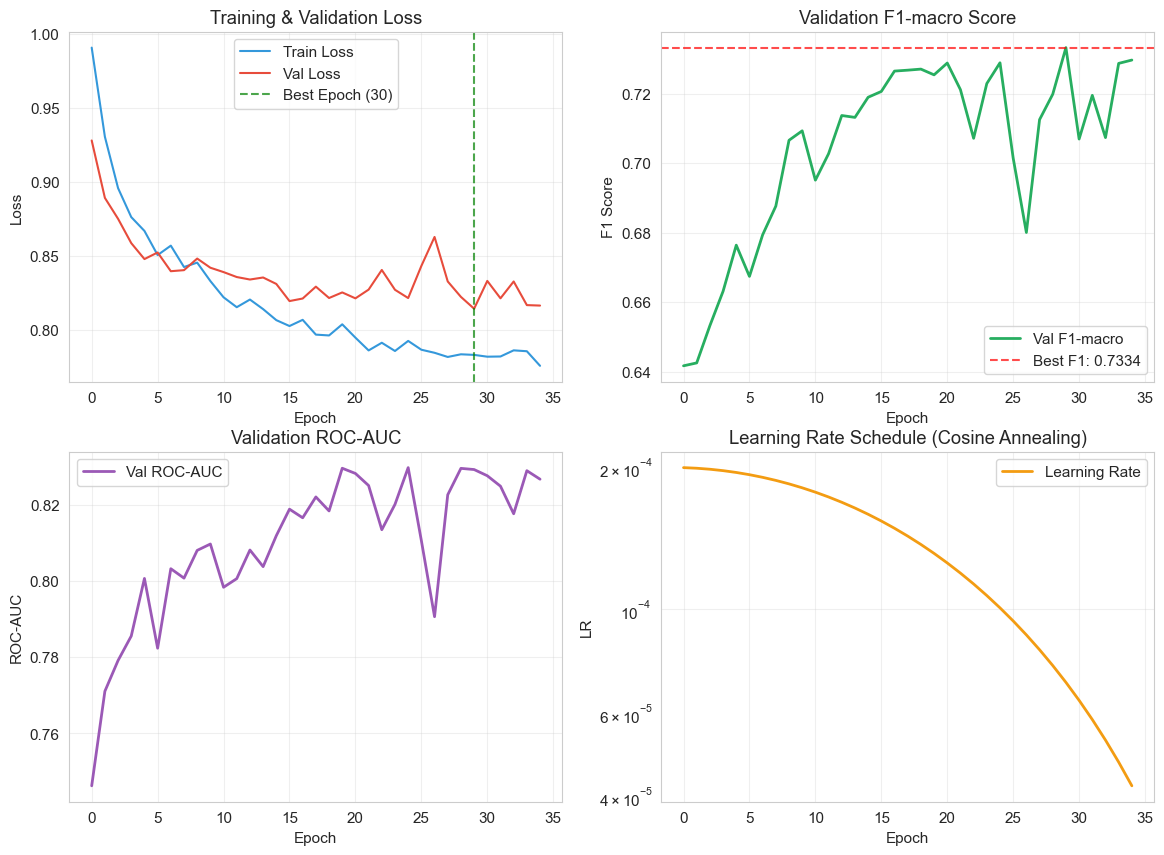

In [89]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

{'batch_size': 128, 'epochs': 50, 'lr': 0.0005, 'weight_decay': 0.0001, 'patience': 12, 'min_delta': 0.0001, 'label_smoothing': 0.1, 'dropout': 0.5, 'encoder_dropout': 0.355, 'output_dim': 32}


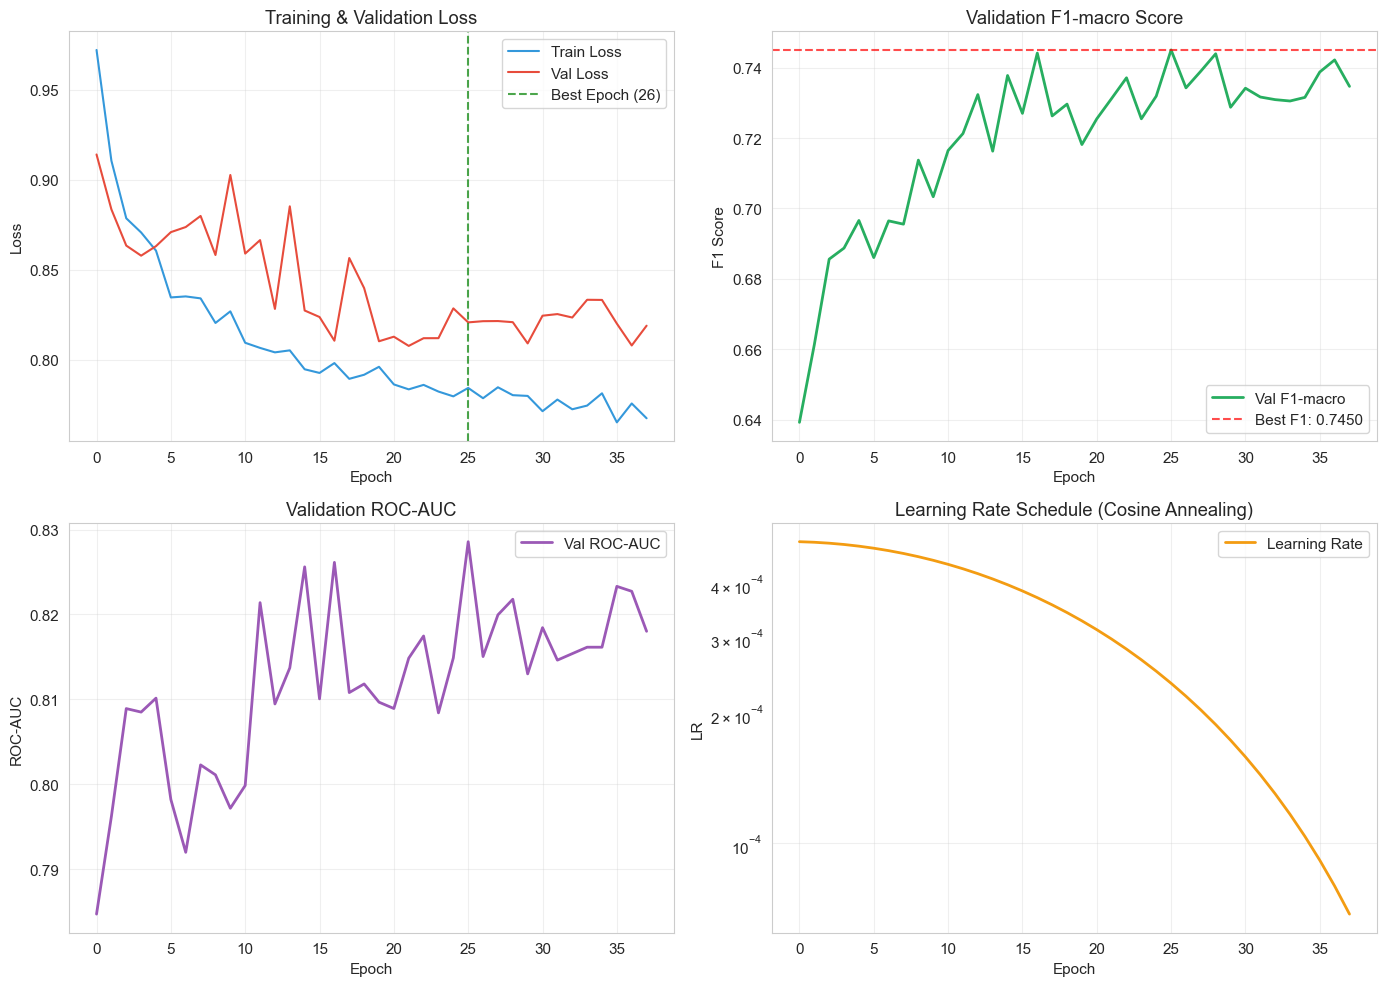

In [ ]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color="#3498db")
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

{'batch_size': 32, 'epochs': 50, 'lr': 0.0005, 'weight_decay': 0.0001, 'patience': 6, 'min_delta': 0.0001, 'label_smoothing': 0.05, 'dropout': 0.5, 'encoder_dropout': 0.35, 'output_dim': 8}


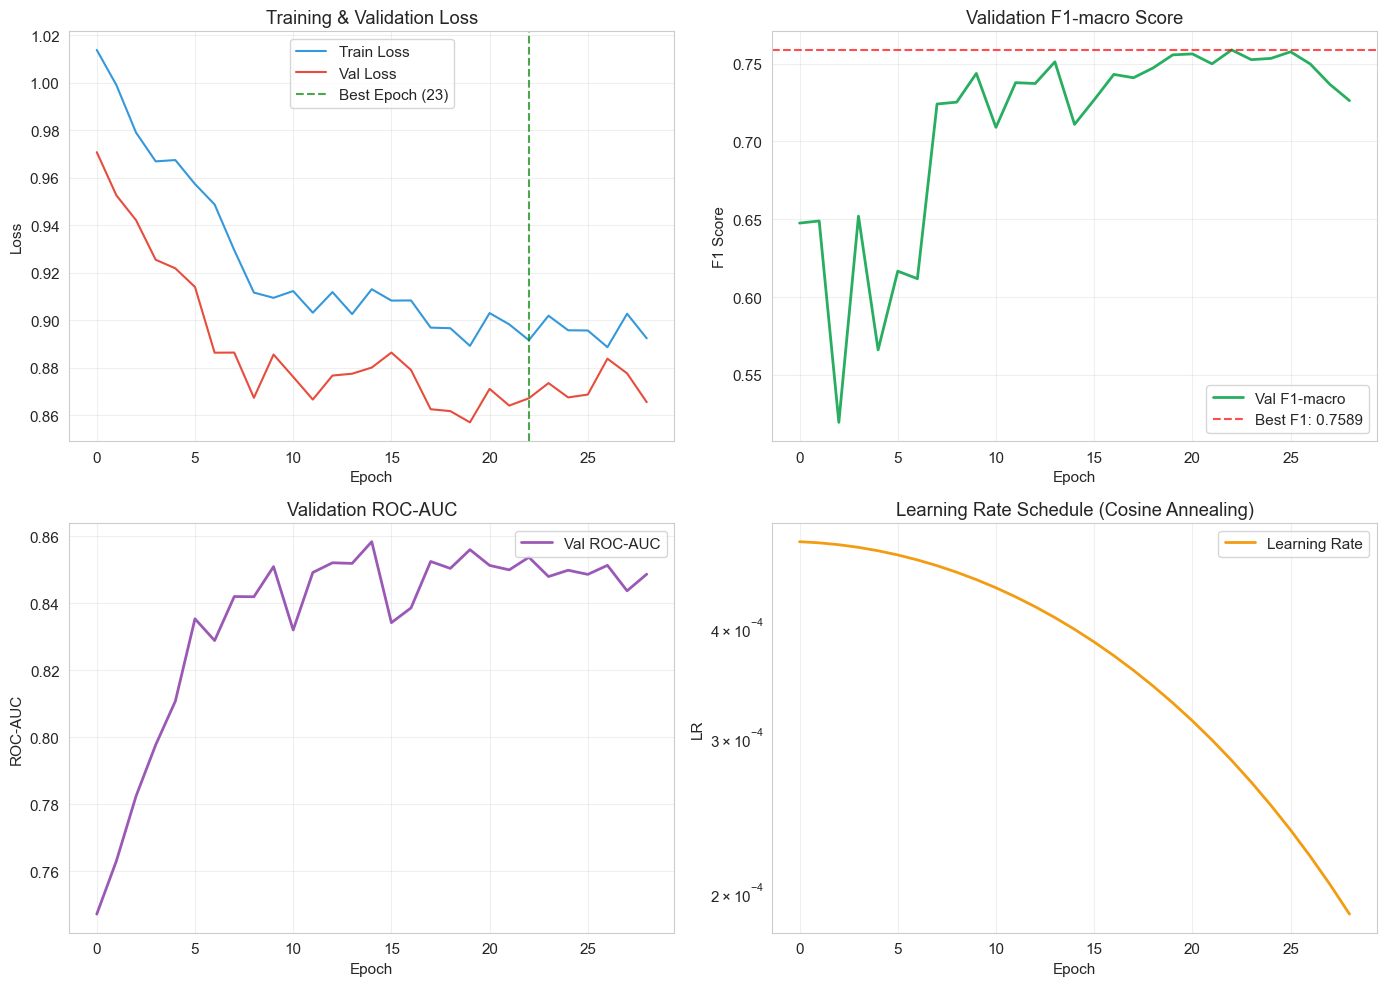

In [48]:
print(CONFIG)
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

output_dim = 16

dropout=0.525, 

encoder_dropout=0.35

CONFIG = {

    'batch_size': 32,
    'epochs': 50,
    'lr': 5e-4,
    'weight_decay': 2e-3,
    'patience': 10,
    'min_delta': 2e-3,
    'label_smoothing': 0.10,
    
}


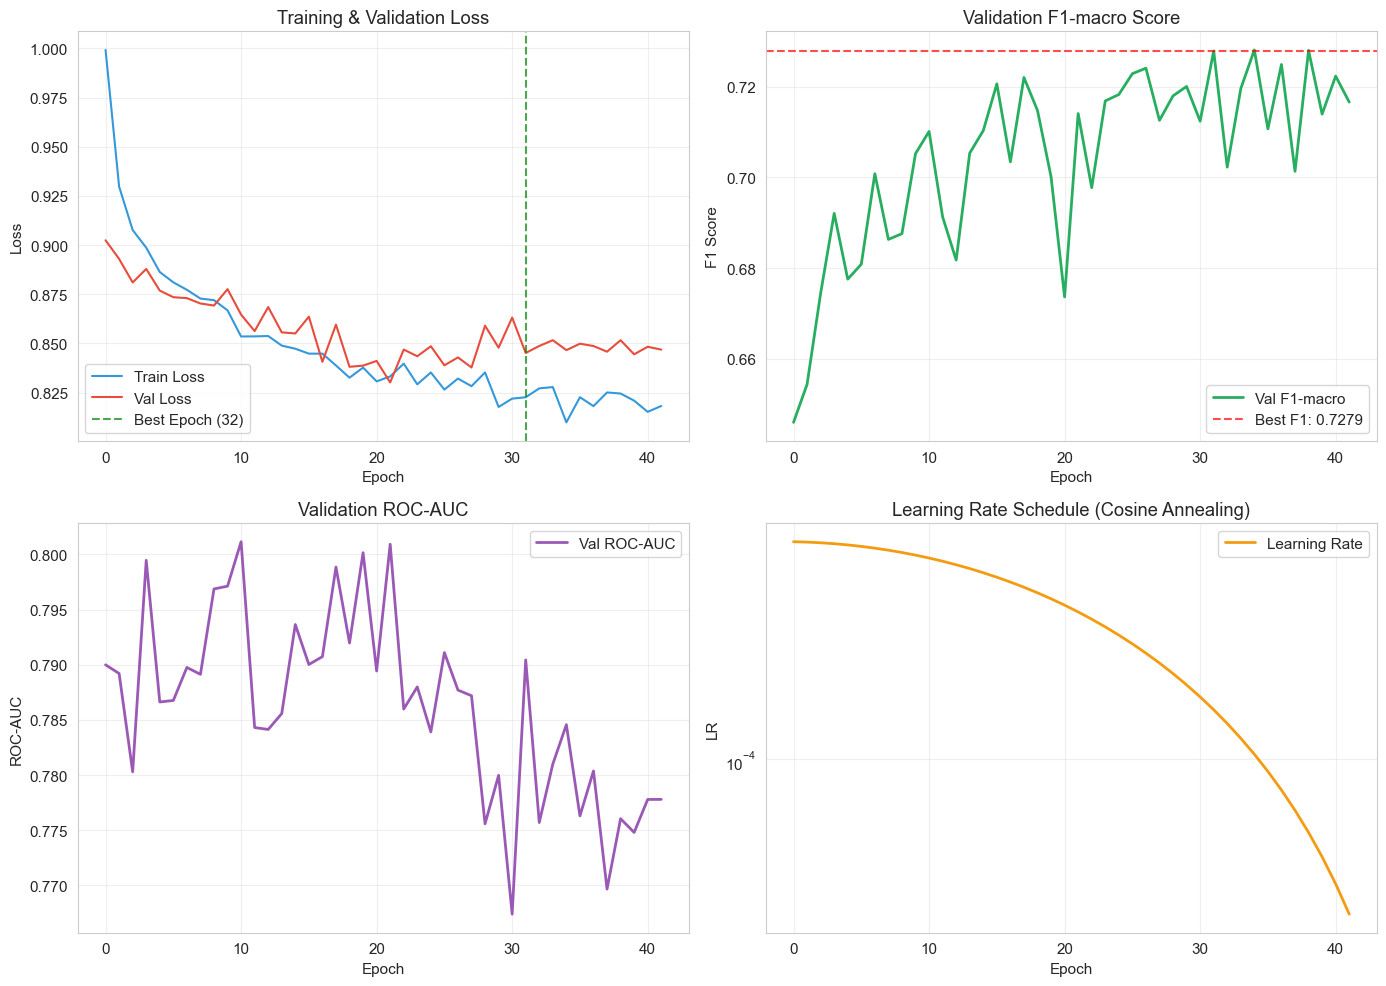

In [32]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

output_dim = 16

dropout=0.4, 

encoder_dropout=0.35

CONFIG = {

    'batch_size': 64,
    'epochs': 50,
    'lr': 5e-4,
    'weight_decay': 1e-3,
    'patience': 10,
    'min_delta': 2e-3,
    'label_smoothing': 0.10,

}

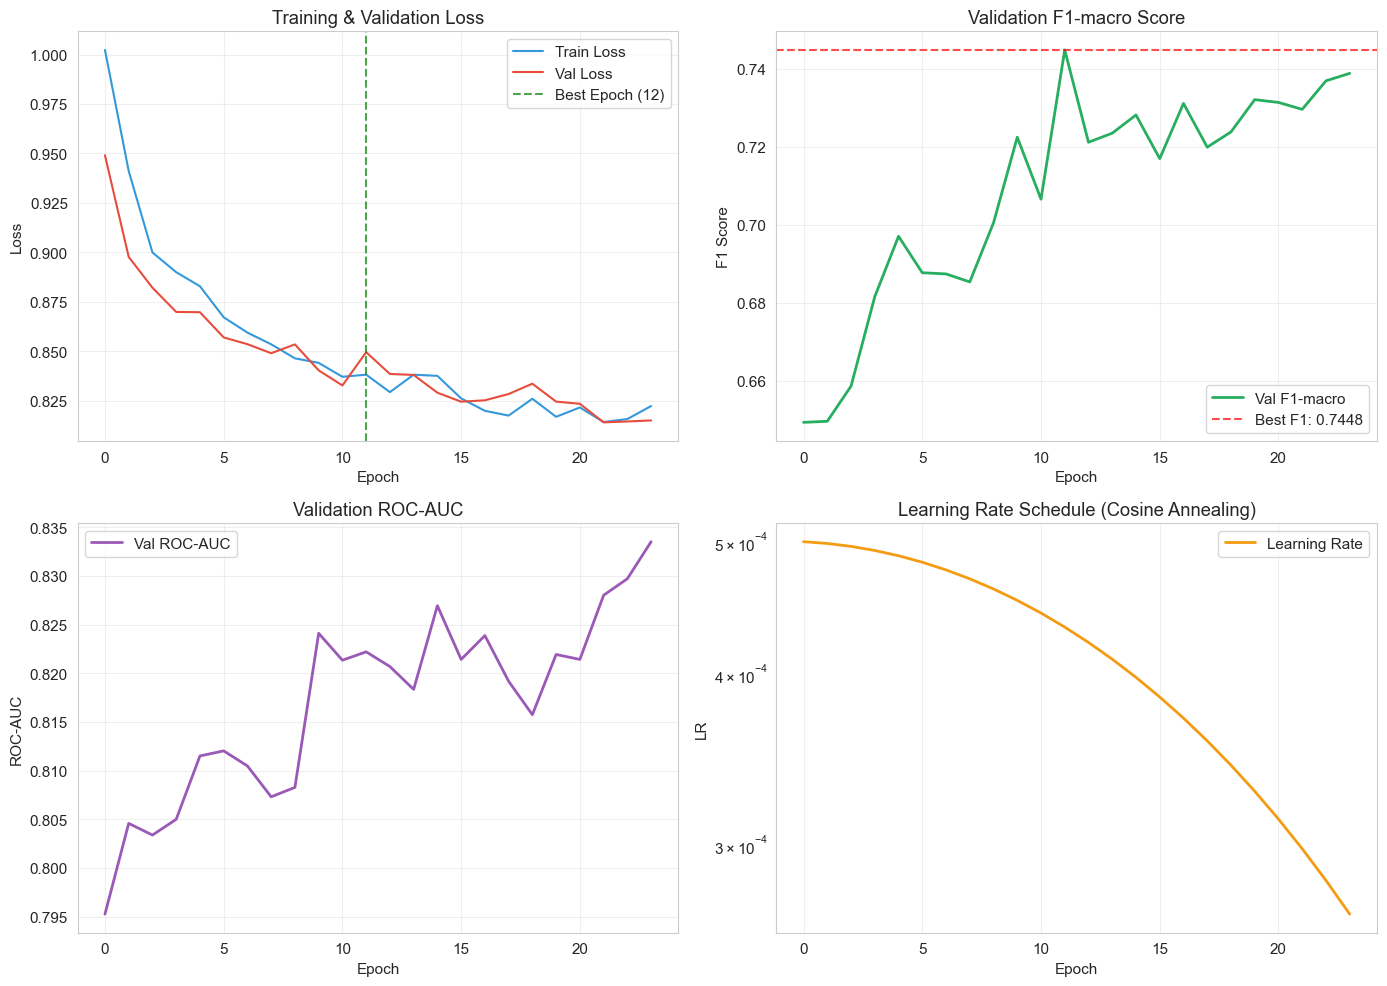

In [25]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка на тестовой выборке (v5.1: FatigueCNN_Simple, без PhysioNet)

Загружаем лучшую модель по F1-macro и оцениваем на held-out test set.

In [25]:
# Загрузка лучшей модели и оценка на тестовой выборке (v5.1: IMU-only, Zenodo + 4TU)
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_v5.pth', weights_only=True))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_imu, y_batch in test_loader:
        X_imu = X_imu.to(DEVICE)

        logits = model(X_imu)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= best_threshold).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (FatigueCNN_Simple, v5.1)")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики (threshold={best_threshold:.3f}):")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Норма (0)', 'Усталость (1)']))

# Per-domain evaluation on test set
print("\n📊 Per-domain Results (test set):")
test_domains = domains[test_idx]
for dom in np.unique(test_domains):
    dom_mask = test_domains == dom
    dom_y = all_labels[dom_mask]
    dom_prob = all_probs[dom_mask]
    dom_pred = all_preds[dom_mask]
    dom_f1 = f1_score(dom_y, dom_pred, average='macro', zero_division=0)
    try:
        dom_auc = roc_auc_score(dom_y, dom_prob) if len(np.unique(dom_y)) > 1 else float('nan')
    except:
        dom_auc = float('nan')
    print(f"   {dom:15s}: n={dom_mask.sum()}, F1={dom_f1:.4f}, AUC={format_metric(dom_auc)}")

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (FatigueCNN_Simple, v5.1)

📊 Метрики (threshold=0.500):
   F1-macro:          0.6375
   F1-weighted:       0.7277
   Balanced Accuracy: 0.6257
   ROC-AUC:           0.6506
   PR-AUC:            0.5291

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.78      0.93      0.85      4165
Усталость (1)       0.64      0.32      0.43      1647

     accuracy                           0.76      5812
    macro avg       0.71      0.63      0.64      5812
 weighted avg       0.74      0.76      0.73      5812


📊 Per-domain Results (test set):
   4tu            : n=4636, F1=0.4348, AUC=0.5332
   zenodo         : n=1176, F1=0.6968, AUC=0.8537


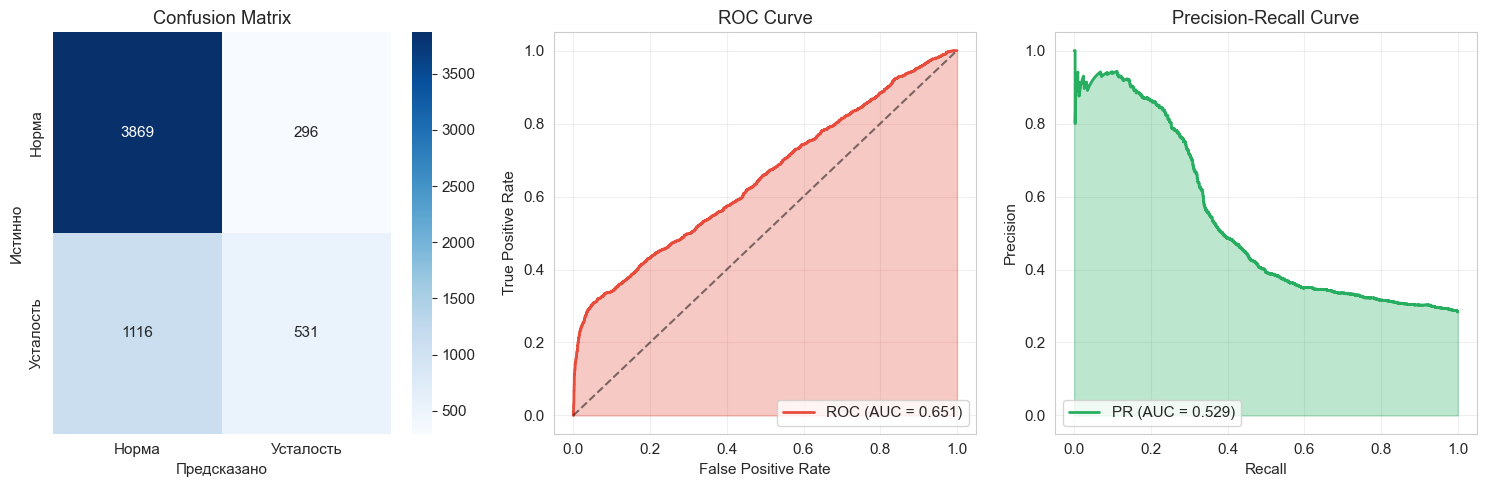

In [26]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию на 2 доменах (Zenodo + 4TU), где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [27]:
# LOSO Evaluation (v5.1: FatigueCNN_Simple, IMU-only, Zenodo + 4TU)
def loso_evaluation(X_imu, y, subjects, domains_arr,
                    n_folds=15, epochs=30, min_windows=30, patience=5):
    """LOSO evaluation with fold limit, early stopping, and per-domain reporting."""

    folds = create_loso_folds(subjects)

    # Filter out subjects with too few windows
    folds = [f for f in folds if len(f['test_idx']) >= min_windows]
    print(f"   Фолдов после фильтра (>={min_windows} окон): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]

    results = []

    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        tr_idx = fold['train_idx']
        te_idx = fold['test_idx']
        test_subject = fold['test_subject']

        # Check both classes present in test
        if len(np.unique(y[te_idx])) < 2:
            continue

        # Split train into train_sub (90%) + val_sub (10%) for early stopping
        from sklearn.model_selection import StratifiedShuffleSplit
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
            sub_tr, sub_val = next(sss.split(tr_idx, y[tr_idx]))
            val_idx = tr_idx[sub_val]
            tr_sub_idx = tr_idx[sub_tr]
        except ValueError:
            tr_sub_idx = tr_idx
            val_idx = te_idx  # fallback

        train_ds = FatigueDataset(X_imu[tr_sub_idx], y[tr_sub_idx])
        val_ds = FatigueDataset(X_imu[val_idx], y[val_idx], augment=False)
        test_ds = FatigueDataset(X_imu[te_idx], y[te_idx], augment=False)

        train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

        fold_model = FatigueCNN_Simple(imu_channels=IMU_CHANNELS).to(DEVICE)

        pw = compute_class_weights(y[tr_sub_idx])
        crit = LabelSmoothingBCELoss(smoothing=CONFIG['label_smoothing'], pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(fold_model.parameters(), lr=0.0003, weight_decay=3e-4)

        # Training with early stopping on mini-val
        best_val_f1 = -np.inf
        best_state = None
        no_improve = 0

        for ep in range(epochs):
            train_epoch(fold_model, train_loader, opt, crit, DEVICE)
            val_loss, val_m = validate(fold_model, val_loader, crit, DEVICE)
            if val_m['f1_macro'] > best_val_f1 + 1e-4:
                best_val_f1 = val_m['f1_macro']
                best_state = {k: v.cpu().clone() for k, v in fold_model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        # Restore best model
        if best_state is not None:
            fold_model.load_state_dict(best_state)

        _, fold_metrics = validate(fold_model, test_loader, crit, DEVICE)

        # Determine domain of test subject
        test_domain = domains_arr[te_idx][0] if len(te_idx) > 0 else "unknown"

        results.append({
            'subject': test_subject,
            'domain': test_domain,
            'f1_macro': fold_metrics['f1_macro'],
            'roc_auc': fold_metrics['roc_auc'],
            'n_samples': len(te_idx),
        })

    return pd.DataFrame(results)


# Run LOSO (v5.1: 30 folds, FatigueCNN_Simple, Zenodo + 4TU only)
print("Running LOSO validation (v5.1: up to 30 folds, FatigueCNN_Simple, Zenodo + 4TU)...")
loso_results = loso_evaluation(
    X_imu_all, y_all, subjects, domains,
    n_folds=15, epochs=20, min_windows=30, patience=CONFIG['patience'],
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueCNN_Simple, v5.1: без PhysioNet)")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\nOverall Summary:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean(skipna=True):.4f} ± {loso_results['roc_auc'].std(skipna=True):.4f}")

# Per-domain LOSO summary
print("\nPer-domain LOSO:")
for dom in loso_results['domain'].unique():
    dom_df = loso_results[loso_results['domain'] == dom]
    print(f"   {dom}: F1={dom_df['f1_macro'].mean():.4f}±{dom_df['f1_macro'].std():.4f}, "
          f"AUC={dom_df['roc_auc'].mean(skipna=True):.4f}, folds={len(dom_df)}")

Running LOSO validation (v5.1: up to 30 folds, FatigueCNN_Simple, Zenodo + 4TU)...
   Фолдов после фильтра (>=30 окон): 26


LOSO Folds: 100%|██████████| 15/15 [09:25<00:00, 37.70s/it]


LOSO RESULTS (FatigueCNN_Simple, v5.1: без PhysioNet)
  subject domain  f1_macro  roc_auc  n_samples
 zenodo_9 zenodo  0.980229 0.986596        407
    4tu_5    4tu  0.434812 0.641395       2510
zenodo_20 zenodo  0.447365 0.705866        420
    4tu_8    4tu  0.444887 0.446286       2066
    4tu_4    4tu  0.434811 0.586875       2614
 zenodo_4 zenodo  0.528959 0.730070        251
zenodo_11 zenodo  0.597529 0.717196        368
zenodo_22 zenodo  0.519471 0.742894        322
    4tu_1    4tu  0.558707 0.714748       2012
 zenodo_6 zenodo  0.567347 0.935580        318
zenodo_21 zenodo  0.577617 0.822336        362
zenodo_12 zenodo  0.923001 0.990439        235
    4tu_3    4tu  0.696522 0.835459       2601
zenodo_15 zenodo  0.543706 0.636920        261
zenodo_17 zenodo  0.954617 0.992891        419

Overall Summary:
   F1-macro:  0.6140 ± 0.1892
   ROC-AUC:   0.7657 ± 0.1613

Per-domain LOSO:
   zenodo: F1=0.6640±0.2037, AUC=0.8261, folds=10
   4tu: F1=0.5139±0.1147, AUC=0.6450, folds=5


## 8. Персонализация (fine-tuning, v5.1: IMU-only, Zenodo + 4TU)

Дообучение модели `FatigueCNN_Simple` под конкретного спортсмена:
- **Стадия 1:** замораживаем энкодер, обучаем только classifier
- **Стадия 2:** размораживаем conv3 + attention, fine-tune с lr/10

In [29]:
import copy

def personalize_model(base_model, X_imu_subj, y_subj, epochs=20, lr=0.001):
    """
    Fine-tune model for a specific athlete (v5.1: IMU-only).

    Stage 1: Freeze encoder, train only classifier
    Stage 2: Unfreeze top conv layer + attention, fine-tune
    """
    model = copy.deepcopy(base_model)

    # Stage 1: freeze encoder
    for param in model.imu_encoder.parameters():
        param.requires_grad = False

    dataset = FatigueDataset(X_imu_subj, y_subj, augment=False)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

    pw = compute_class_weights(y_subj)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: classifier only
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    # Stage 2: unfreeze top conv layer + attention
    for param in model.imu_encoder.conv3.parameters():
        param.requires_grad = True
    if hasattr(model.imu_encoder, 'attention'):
        for param in model.imu_encoder.attention.parameters():
            param.requires_grad = True

    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr / 10,
    )
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    return model


# v5.1: Select subject with enough windows and both classes
MIN_PERS_WINDOWS = 50
np.random.seed(SEED)
candidates = []
for s in np.unique(subjects):
    s_mask = subjects == s
    s_y = y_all[s_mask]
    if len(s_y) >= MIN_PERS_WINDOWS and len(np.unique(s_y)) == 2:
        candidates.append(s)

print(f"Personalization candidates (>={MIN_PERS_WINDOWS} windows, both classes): {len(candidates)}")
target_subject = np.random.choice(candidates) if candidates else np.unique(subjects)[0]
subj_mask = subjects == target_subject
X_imu_subj = X_imu_all[subj_mask]
y_subj = y_all[subj_mask]

print(f"\nTarget subject: {target_subject}")
print(f"Windows: {len(y_subj)}")
print(f"Balance: {y_subj.mean():.1%} positive")

# Stratified split
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
tr_idx_p, te_idx_p = next(sss.split(X_imu_subj, y_subj))

X_imu_tr = X_imu_subj[tr_idx_p]
X_imu_te = X_imu_subj[te_idx_p]
y_tr, y_te = y_subj[tr_idx_p], y_subj[te_idx_p]

print(f"Train: {len(y_tr)} ({y_tr.mean():.1%} pos), Test: {len(y_te)} ({y_te.mean():.1%} pos)")

# Guard: ensure both classes in test split
assert len(np.unique(y_te)) == 2, f"Test split has only one class for {target_subject}."

# Load best model as base
base_model = FatigueCNN_Simple(imu_channels=IMU_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_v5.pth', weights_only=True))

# Evaluate base model
base_model.eval()
test_ds = FatigueDataset(X_imu_te, y_te, augment=False)
test_ld = DataLoader(test_ds, batch_size=32, shuffle=False)
crit = nn.BCEWithLogitsLoss()
_, base_metrics = validate(base_model, test_ld, crit, DEVICE, threshold=best_threshold)

print(f"\nBase model on {target_subject} (threshold={best_threshold:.3f}):")
print(f"   F1-macro: {base_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:  {format_metric(base_metrics['roc_auc'])}")

# Personalize
pers_model = personalize_model(base_model, X_imu_tr, y_tr, epochs=20)
_, pers_metrics = validate(pers_model, test_ld, crit, DEVICE, threshold=best_threshold)

print(f"\nPersonalized model (threshold={best_threshold:.3f}):")
print(f"   F1-macro: {pers_metrics['f1_macro']:.4f} (Δ = {pers_metrics['f1_macro'] - base_metrics['f1_macro']:+.4f})")
roc_delta = (pers_metrics['roc_auc'] or 0) - (base_metrics['roc_auc'] or 0)
print(f"   ROC-AUC:  {format_metric(pers_metrics['roc_auc'])} (Δ = {roc_delta:+.4f})")

Personalization candidates (>=50 windows, both classes): 26

Target subject: zenodo_5
Windows: 198
Balance: 49.5% positive
Train: 138 (49.3% pos), Test: 60 (50.0% pos)


RuntimeError: Error(s) in loading state_dict for FatigueCNN_Simple:
	size mismatch for imu_encoder.conv1.0.weight: copying a param with shape torch.Size([32, 6, 7]) from checkpoint, the shape in current model is torch.Size([16, 6, 7]).
	size mismatch for imu_encoder.conv1.0.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for imu_encoder.conv1.1.weight: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for imu_encoder.conv1.1.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for imu_encoder.conv1.1.running_mean: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for imu_encoder.conv1.1.running_var: copying a param with shape torch.Size([32]) from checkpoint, the shape in current mode

## 10. Степень утомления (Fatigue Degree)

Непрерывный выход модели sigmoid ∈ [0, 1] интерпретируется как степень утомления.
Визуализация по субъекту: как изменяется fatigue degree в динамике по окнам.

In [30]:
# ── Количественная оценка степени переутомления (v5.1: IMU-only) ──

def fatigue_degree_report(model, X_imu, y_true,
                           threshold=0.5, subject_id="Unknown", device=DEVICE):
    """
    Compute continuous fatigue degree for a subject's windows.
    Returns per-window float [0.0, 1.0] and an aggregate summary.
    """
    model.eval()
    x_imu_t = torch.FloatTensor(X_imu).to(device)

    with torch.no_grad():
        logits = model(x_imu_t)
        degrees = torch.sigmoid(logits).cpu().numpy()

    y_pred = (degrees >= threshold).astype(int)

    def degree_label(d):
        if d < 0.20:   return "Норма"
        elif d < 0.45: return "Лёгкое утомление"
        elif d < threshold: return "Пограничное"
        elif d < 0.75: return "Умеренное"
        else:          return "Выраженное"

    results_df = pd.DataFrame({
        'window':         range(len(degrees)),
        'fatigue_degree': np.round(degrees, 4),
        'level':          [degree_label(d) for d in degrees],
        'predicted':      y_pred,
        'true_label':     y_true.astype(int),
    })

    mean_degree = float(degrees.mean())
    max_degree  = float(degrees.max())

    print(f"\n{'='*55}")
    print(f"  Субъект: {subject_id}")
    print(f"{'='*55}")
    print(f"  Средняя степень переутомления : {mean_degree:.4f}  → {degree_label(mean_degree)}")
    print(f"  Максимальная степень          : {max_degree:.4f}  → {degree_label(max_degree)}")
    print(f"  Предсказано переутомлённых окон: {y_pred.sum()}/{len(y_pred)}"
          f" ({y_pred.mean()*100:.1f}%)")
    print(f"  Порог классификации           : {threshold:.3f}")
    print(f"\n  Примеры окон (первые 5):")
    print(results_df.head(5).to_string(index=False))

    return results_df, mean_degree


# ── Оценка базовой и персонализированной модели на целевом субъекте ──

print("\n== БАЗОВАЯ модель ==")
df_base, deg_base = fatigue_degree_report(
    base_model, X_imu_te, y_te,
    threshold=best_threshold, subject_id=f"{target_subject} (base)",
)

print("\n== ПЕРСОНАЛИЗИРОВАННАЯ модель ==")
df_pers, deg_pers = fatigue_degree_report(
    pers_model, X_imu_te, y_te,
    threshold=best_threshold, subject_id=f"{target_subject} (personalized)",
)

# ── Визуализация динамики степени переутомления ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

windows = np.arange(len(df_base))
ax = axes[0]
ax.plot(windows, df_base['fatigue_degree'], color='#3498db', lw=1.5, alpha=0.8, label='Базовая модель')
ax.plot(windows, df_pers['fatigue_degree'], color='#e67e22', lw=1.5, alpha=0.8, label='Персонализированная')
ax.axhline(best_threshold, color='red', linestyle='--', lw=1, label=f'Порог ({best_threshold:.2f})')
ax.fill_between(windows, best_threshold, 1.0, alpha=0.07, color='red')
ax.set_ylabel('Степень переутомления')
ax.set_title(f'Динамика степени переутомления: субъект {target_subject}')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.step(windows, df_base['true_label'], color='black', lw=1.5, where='mid', label='Истинная метка')
ax2.step(windows, df_base['predicted'],  color='#3498db', lw=1.2, where='mid', linestyle='--', label='Пред. (базовая)')
ax2.step(windows, df_pers['predicted'],  color='#e67e22', lw=1.2, where='mid', linestyle=':', label='Пред. (pers.)')
ax2.set_xlabel('Номер окна')
ax2.set_ylabel('Метка (0/1)')
ax2.legend()
ax2.set_ylim(-0.1, 1.4)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fatigue_degree_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nДельта степени (pers vs base): {deg_pers - deg_base:+.4f}")


== БАЗОВАЯ модель ==

  Субъект: zenodo_5 (base)
  Средняя степень переутомления : 0.4410  → Лёгкое утомление
  Максимальная степень          : 0.4415  → Лёгкое утомление
  Предсказано переутомлённых окон: 0/60 (0.0%)
  Порог классификации           : 0.500

  Примеры окон (первые 5):
 window  fatigue_degree            level  predicted  true_label
      0          0.4411 Лёгкое утомление          0           0
      1          0.4410 Лёгкое утомление          0           0
      2          0.4406 Лёгкое утомление          0           1
      3          0.4413 Лёгкое утомление          0           0
      4          0.4410 Лёгкое утомление          0           0

== ПЕРСОНАЛИЗИРОВАННАЯ модель ==


NameError: name 'pers_model' is not defined

## 11. Изменения v5.1: Удаление PhysioNet для борьбы с переобучением

### Ключевые изменения (по сравнению с v5.0)

| Аспект | v5.0 (IMU-only CNN) | v5.1 (без PhysioNet) |
|--------|---------------------|----------------------|
| **Датасеты** | 3 (Zenodo + 4TU + PhysioNet) | **2** (Zenodo + 4TU) |
| **Субъекты** | ~90 | **~38** |
| **Окна** | ~48K | **~25K** (оценка) |
| **Модель** | FatigueCNN_Simple (~27K) | FatigueCNN_Simple (~27K) |
| **IMU каналы** | 6ch (acc+gyro), но PhysioNet только 3ch ACC | **6ch** (все субъекты с полным IMU) |
| **Аугментация** | 7 IMU техник | 7 IMU техник |

### Обоснование удаления PhysioNet

1. **Domain shift**: PhysioNet содержит только ACC (3 канала), gyro обнулён → модель учится обрабатывать два разных распределения входов
2. **Избыточный объём**: ~47% всех окон → доминирует при обучении, несмотря на domain-weighted sampler
3. **Переобучение**: большой объём данных + аугментация → модель переобучается на статистических паттернах PhysioNet
4. **Однородность данных**: Zenodo + 4TU оба содержат полные 6-канальные IMU данные бега → более чистый сигнал

In [ ]:
# ── Анализ overfitting gap (v5.1) ──

print("=" * 65)
print("  АНАЛИЗ ПЕРЕОБУЧЕНИЯ (v5.1: FatigueCNN_Simple, без PhysioNet)")
print("=" * 65)

# Check train vs val gap from history
if len(history['train_loss']) > 0:
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    best_val_f1_hist = max(history['val_f1'])
    best_val_auc_hist = max(history['val_auc'])

    print(f"\n  Final train loss: {final_train_loss:.4f}")
    print(f"  Final val loss:   {final_val_loss:.4f}")
    print(f"  Overfitting gap:  {final_val_loss - final_train_loss:.4f}")
    print(f"  Best val F1:      {best_val_f1_hist:.4f}")
    print(f"  Best val AUC:     {best_val_auc_hist:.4f}")

    # Gap trajectory
    gaps = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
    print(f"\n  Overfitting gap trajectory:")
    print(f"    Epoch  1: {gaps[0]:.4f}")
    if len(gaps) > 5:
        print(f"    Epoch  5: {gaps[4]:.4f}")
    if len(gaps) > 10:
        print(f"    Epoch 10: {gaps[9]:.4f}")
    print(f"    Epoch {len(gaps):2d}: {gaps[-1]:.4f}")

print(f"\n  Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Total train samples: {len(train_dataset)}")
print(f"  Params / samples ratio: {sum(p.numel() for p in model.parameters()) / len(train_dataset):.4f}")

  АНАЛИЗ ПЕРЕОБУЧЕНИЯ (v5.1: FatigueCNN_Simple, без PhysioNet)

  Final train loss: 0.8843
  Final val loss:   0.8857
  Overfitting gap:  0.0015
  Best val F1:      0.6939
  Best val AUC:     0.8071

  Overfitting gap trajectory:
    Epoch  1: -0.0201
    Epoch  5: -0.0132
    Epoch 10: 0.0023
    Epoch 26: 0.0015

  Model parameters: 3,082
  Total train samples: 13225
  Params / samples ratio: 0.2330


## 9. Сохранение результатов (v5.1)

In [ ]:
import json

total_params = sum(p.numel() for p in model.parameters())

summary = {
    'version': 'v5.1',
    'model': 'FatigueCNN_Simple',
    'architecture': 'CNN (IMU encoder) + Temporal Attention + Classifier',
    'changes_vs_v5': [
        'Removed PhysioNet dataset (~47% windows, ACC-only → domain shift)',
        'Kept Zenodo + 4TU (both have full 6-ch IMU: acc + gyro)',
    ],
    'changes_vs_v4': [
        'Removed Physio branch (BVP, EDA, TEMP, HR)',
        'Removed LSTM block',
        'Removed WSD4FEDSRM dataset',
        'Removed PhysioNet dataset',
        'Reduced model: 80K → 27K params',
    ],
    'total_parameters': int(total_params),
    'imu_channels': IMU_CHANNELS,
    'window_size': X_imu_all.shape[1],
    'total_windows': len(y_all),
    'domains': list(np.unique(domains)),
    'unique_subjects': len(np.unique(subjects)),
    'class_balance': f"{y_all.mean():.1%} positive",
    'augmentation': 'gaussian_noise, time_warp, channel_dropout, magnitude_scale, '
                    'window_slice, time_reverse, imu_rotate',
    'best_model_path': str(RESULTS_DIR / 'best_model_v5.pth'),
    'best_threshold': float(best_threshold),
    'best_val_f1': float(best_val_f1),
}

print("=" * 60)
print("     ИТОГОВАЯ СВОДКА FatigueCNN_Simple (v5.1: без PhysioNet)")
print("=" * 60)
for k, v in summary.items():
    val = str(v) if not isinstance(v, list) else ', '.join(v)
    print(f"  {k:25s}: {val}")
print("=" * 60)

summary_path = RESULTS_DIR / 'experiment_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\nSummary saved: {summary_path}")

     ИТОГОВАЯ СВОДКА FatigueCNN_Simple (v5.1: без PhysioNet)
  version                  : v5.1
  model                    : FatigueCNN_Simple
  architecture             : CNN (IMU encoder) + Temporal Attention + Classifier
  changes_vs_v5            : Removed PhysioNet dataset (~47% windows, ACC-only → domain shift), Kept Zenodo + 4TU (both have full 6-ch IMU: acc + gyro)
  changes_vs_v4            : Removed Physio branch (BVP, EDA, TEMP, HR), Removed LSTM block, Removed WSD4FEDSRM dataset, Removed PhysioNet dataset, Reduced model: 80K → 27K params
  total_parameters         : 3082
  imu_channels             : 6
  window_size              : 100
  total_windows            : 22416
  domains                  : 4tu, zenodo
  unique_subjects          : 26
  class_balance            : 30.6% positive
  augmentation             : gaussian_noise, time_warp, channel_dropout, magnitude_scale, window_slice, time_reverse, imu_rotate
  best_model_path          : D:\Github\afc_lab\results_v5_no_physi

# Выводы (v5.1: без PhysioNet)

## Проблема переобучения

Модель v5.0 (`FatigueCNN_Simple`, IMU-only, 3 домена) продолжала переобучаться несмотря на:
- Удаление LSTM и Physio-ветки
- Снижение параметров до ~27K
- Подбор гиперпараметров (lr, weight_decay, dropout, patience)

**Гипотеза:** PhysioNet (~47% окон) создаёт domain shift (только ACC без gyro) и, в сочетании с аугментацией, приводит к переобучению.

## Решение: удаление PhysioNet (v5.1)

| Компонент | v5.0 | v5.1 |
|-----------|------|------|
| Датасеты | 3 (Zenodo + 4TU + PhysioNet) | **2** (Zenodo + 4TU) |
| Субъектов | ~90 | **~38** |
| IMU каналы | 6ch (PhysioNet: 3ch ACC) | **6ch** (все полные) |
| Модель | FatigueCNN_Simple (~27K) | FatigueCNN_Simple (~27K) |
| Аугментация | 7 IMU техник | 7 IMU техник |

## Датасеты

| Источник | Модальности | Субъектов |
|----------|-------------|-----------|
| Zenodo   | IMU (acc + gyro) | 19 |
| 4TU      | IMU (acc + gyro) | 19 |

## Оценка

- **Hold-out**: стратифицированное разбиение 60/20/20 с учётом доменов
- **LOSO**: кросс-валидация Leave-One-Subject-Out (до 30 фолдов)
- **Персонализация**: двухэтапная (freeze → fine-tune) для конкретного спортсмена
- **Анализ overfitting gap**: отслеживание train-val divergence

## Ожидания

- Более однородные данные (оба домена — бег с полным IMU) → меньший domain shift
- Меньше данных → аугментация лучше масштабируется без переобучения
- Лучший баланс params/samples для обобщения